<a href="https://colab.research.google.com/github/sdg331/BDA404/blob/main/culture_access_gap_senior_analysis_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 2024 문화역세권 데이터 기반 지역별 문화 접근성 격차 분석

공모전 제출용 분석 노트북

- 공모 분야: 데이터 분석
- 분석 도구: Python
- 핵심 데이터: 한국문화정보원_4050 문화역세권_20241231
- 확장 데이터: 디지털 문화역세권, 지역문화실태조사 참고 가능
- 분석 목표: 4050 인구 규모 대비 문화시설 접근성 격차와 정책 우선지역 도출

## 0. 분석 질문 정의

이번 분석은 단순히 문화시설이 많은 지역을 찾는 것이 아니라, 다음 질문에 답하는 방식으로 진행한다.

1. 4050 인구가 많은 지역에 문화시설이 충분히 배치되어 있는가?
2. 도서관·박물관·미술관·공연장 중 어떤 시설 유형의 접근성이 낮은가?
3. 시설 수는 많은데 인구 대비 접근성은 낮은 지역이 존재하는가?
4. 문화 접근성 취약 지역을 정책 우선순위로 정렬하면 어떤 지역이 먼저 나오는가?
5. 지역별 부족 시설 유형에 따라 어떤 문화생활 추천 또는 문화정책 방향이 적합한가?

## 1. 기본 패키지와 시각화 설정

In [ ]:
import os
import glob
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import seaborn as sns
    HAS_SEABORN = True
except Exception:
    HAS_SEABORN = False

from IPython.display import display_html

pd.set_option("display.max_columns", 80)
pd.set_option("display.max_rows", 120)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

import platform
if platform.system() == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
elif platform.system() == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"
else:
    plt.rcParams["font.family"] = "NanumGothic"

plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.figsize"] = (7, 4)

print("pandas:", pd.__version__)
print("numpy:", np.__version__)
print("seaborn 사용 가능:", HAS_SEABORN)

pandas: 2.2.2
numpy: 2.0.2
seaborn 사용 가능: True


In [ ]:
# seaborn 설치
!pip install seaborn
!pip install koreanize-matplotlib
import koreanize_matplotlib
%config InlineBackend.figure_format = 'retina'

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 61.0 MB/s eta 0:00:00


In [ ]:
# 표를 나란히 보기 위한 함수
def show_tables(*tables, titles=None):
    html = ""
    for i, table in enumerate(tables):
        title = "" if titles is None else f"<b>{titles[i]}</b><br>"
        html += f"<div style='display:inline-block; vertical-align:top; margin-right:18px;'>{title}"
        html += table.to_html()
        html += "</div>"
    display_html(html, raw=True)

def format_int(x):
    try:
        return f"{int(round(x)):,}"
    except Exception:
        return x

def minmax(s):
    if s.max() == s.min():
        return pd.Series(np.zeros(len(s)), index=s.index)
    return (s - s.min()) / (s.max() - s.min())

## 2. 데이터 불러오기

아래 파일을 공공데이터포털에서 내려받아 노트북과 같은 폴더에 둔다.

- 한국문화정보원_4050 문화역세권_20241231.csv

파일명이 조금 달라도 `4050`, `문화역세권`이 포함되어 있으면 자동으로 탐색한다.

In [ ]:
# 같은 폴더의 문화역세권 관련 CSV 탐색
files = []
patterns = [
    "*4050*문화역세권*.csv",
    "*문화역세권*4050*.csv",
    "*4050*.csv",
    "*문화*역세권*.csv"
]

for p in patterns:
    files.extend(glob.glob(p))

files = sorted(list(set(files)))
files

['한국문화정보원_4050 문화역세권_20241231.csv']

In [ ]:
# 원본 파일이 없을 때 실행 흐름을 확인하기 위한 샘플 생성
# 제출 전에는 반드시 공공데이터포털 원본 CSV를 같은 폴더에 넣고 다시 실행

def make_sample_data():
    np.random.seed(7)
    sido_list = ["서울", "부산", "대구", "인천", "광주", "대전", "울산", "세종", "경기", "강원", "충북", "충남", "전북", "전남", "경북", "경남", "제주"]
    names = {
        "서울": ["강남구", "관악구", "도봉구", "마포구", "송파구", "중랑구"],
        "부산": ["해운대구", "부산진구", "사하구", "금정구"],
        "대구": ["달서구", "수성구", "북구", "동구"],
        "인천": ["남동구", "부평구", "서구", "연수구"],
        "광주": ["북구", "광산구", "서구"],
        "대전": ["서구", "유성구", "동구"],
        "울산": ["남구", "울주군", "중구"],
        "세종": ["세종시"],
        "경기": ["수원시", "고양시", "성남시", "용인시", "부천시", "남양주시", "평택시", "화성시"],
        "강원": ["춘천시", "원주시", "강릉시", "속초시"],
        "충북": ["청주시", "충주시", "제천시"],
        "충남": ["천안시", "아산시", "공주시", "서산시"],
        "전북": ["전주시", "군산시", "익산시", "정읍시"],
        "전남": ["목포시", "여수시", "순천시", "나주시"],
        "경북": ["포항시", "구미시", "경주시", "안동시"],
        "경남": ["창원시", "김해시", "진주시", "양산시"],
        "제주": ["제주시", "서귀포시"]
    }
    rows = []
    code = 10000
    for sido in sido_list:
        for sig in names[sido]:
            pop = int(np.random.randint(80000, 850000))
            pop4050 = int(pop * np.random.uniform(0.27, 0.38))
            base = pop / 120000
            library = max(1, int(np.random.poisson(base * 1.9)))
            museum = max(0, int(np.random.poisson(base * 0.8)))
            art = max(0, int(np.random.poisson(base * 0.55)))
            performance = max(0, int(np.random.poisson(base * 0.9)))
            if sig in ["도봉구", "울주군", "서귀포시", "제천시", "정읍시", "나주시", "평택시"]:
                museum = max(0, museum - 1)
                art = max(0, art - 1)
                performance = max(0, performance - 1)
            rows.append([sido, sig, str(code), pop, pop4050, library, museum, art, performance, "20241231"])
            code += 1
    return pd.DataFrame(rows, columns=[
        "시도명", "시군구명", "시군구코드", "시군구인구수", "4050대인구수",
        "도서관수", "박물관수", "미술관수", "공연장수", "기준일자"
    ])

def read_csv_safely(path):
    for enc in ["utf-8-sig", "cp949", "euc-kr", "utf-8"]:
        try:
            return pd.read_csv(path, encoding=enc), enc
        except Exception:
            pass
    raise ValueError("CSV 인코딩을 읽지 못했습니다.")

if len(files) > 0:
    data_path = files[0]
    raw, used_encoding = read_csv_safely(data_path)
    print("원본 파일 사용:", data_path)
    print("인코딩:", used_encoding)
else:
    raw = make_sample_data()
    print("원본 CSV가 없어 샘플 데이터로 구조만 실행합니다.")
    print("제출 전 원본 CSV를 같은 폴더에 넣고 다시 실행해야 합니다.")

raw.head()

원본 파일 사용: 한국문화정보원_4050 문화역세권_20241231.csv
인코딩: utf-8-sig


,시도명,시군구명,시군구코드,시군구인구수,4050대인구수,도서관수,박물관수,미술관수,공연장수,도서관40대50대인구수,박물관40대50대인구수,미술관40대50대인구수,공연장40대50대인구수,파일명,기준일자
0,서울특별시,종로구,11110,167487,54824,9,38,19,321,"6,091.000","1,442.000","2,885.000",170.000,KC_614_FRT_FFT_CLT_STATN_BIZAEA_2024,2024-12-31
1,서울특별시,중구,11140,151422,50061,9,17,3,74,"5,562.000","2,944.000","16,687.000",676.000,KC_614_FRT_FFT_CLT_STATN_BIZAEA_2024,2024-12-31
2,서울특별시,용산구,11170,232639,86032,4,8,4,66,"21,508.000","10,754.000","21,508.000","1,303.000",KC_614_FRT_FFT_CLT_STATN_BIZAEA_2024,2024-12-31
3,서울특별시,성동구,11200,273609,92116,7,2,2,56,"13,159.000","46,058.000","46,058.000","1,644.000",KC_614_FRT_FFT_CLT_STATN_BIZAEA_2024,2024-12-31
4,서울특별시,광진구,11215,346378,110318,7,3,0,31,"15,759.000","36,772.000",NaN,"3,558.000",KC_614_FRT_FFT_CLT_STATN_BIZAEA_2024,2024-12-31


In [ ]:
print("행/열:", raw.shape)
print("컬럼:", raw.columns.tolist())
raw.info()

행/열: (252, 15)
컬럼: ['시도명', '시군구명', '시군구코드', '시군구인구수', '4050대인구수', '도서관수', '박물관수', '미술관수', '공연장수', '도서관40대50대인구수', '박물관40대50대인구수', '미술관40대50대인구수', '공연장40대50대인구수', '파일명', '기준일자']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 252 entries, 0 to 251
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   시도명           252 non-null    object 
 1   시군구명          252 non-null    object 
 2   시군구코드         252 non-null    int64  
 3   시군구인구수        252 non-null    int64  
 4   4050대인구수      252 non-null    int64  
 5   도서관수          252 non-null    int64  
 6   박물관수          252 non-null    int64  
 7   미술관수          252 non-null    int64  
 8   공연장수          252 non-null    int64  
 9   도서관40대50대인구수  237 non-null    float64
 10  박물관40대50대인구수  224 non-null    float64
 11  미술관40대50대인구수  132 non-null    float64
 12  공연장40대50대인구수  250 non-null    float64
 13  파일명           252 non-null    object 
 14  기준일자          252 non-nul

In [ ]:
show_tables(raw.head(), raw.tail(), titles=["head", "tail"])

,시도명,시군구명,시군구코드,시군구인구수,4050대인구수,도서관수,박물관수,미술관수,공연장수,도서관40대50대인구수,박물관40대50대인구수,미술관40대50대인구수,공연장40대50대인구수,파일명,기준일자
0,서울특별시,종로구,11110,167487,54824,9,38,19,321,"6,091.000","1,442.000","2,885.000",170.000,KC_614_FRT_FFT_CLT_STATN_BIZAEA_2024,2024-12-31
1,서울특별시,중구,11140,151422,50061,9,17,3,74,"5,562.000","2,944.000","16,687.000",676.000,KC_614_FRT_FFT_CLT_STATN_BIZAEA_2024,2024-12-31
2,서울특별시,용산구,11170,232639,86032,4,8,4,66,"21,508.000","10,754.000","21,508.000","1,303.000",KC_614_FRT_FFT_CLT_STATN_BIZAEA_2024,2024-12-31
3,서울특별시,성동구,11200,273609,92116,7,2,2,56,"13,159.000","46,058.000","46,058.000","1,644.000",KC_614_FRT_FFT_CLT_STATN_BIZAEA_2024,2024-12-31
4,서울특별시,광진구,11215,346378,110318,7,3,0,31,"15,759.000","36,772.000",NaN,"3,558.000",KC_614_FRT_FFT_CLT_STATN_BIZAEA_2024,2024-12-31
,시도명,시군구명,시군구코드,시군구인구수,4050대인구수,도서관수,박물관수,미술관수,공연장수,도서관40대50대인구수,박물관40대50대인구수,미술관40대50대인구수,공연장40대50대인구수,파일명,기준일자
247,전북특별자치도,장수군,52740,15717,4766,0,1,1,2,NaN,"4,766.000","4,766.000","2,383.000",KC_614_FRT_FFT_CLT_STATN_BIZAEA_2024,2024-12-31
248,전북특별자치도,임실군,52750,17407,4641,0,1,0,1,NaN,"4,641.000",NaN,"4,641.000",KC_614_FRT_FFT_CLT_STATN_BIZAEA_2024,2024-12-31
249,전북특별자치도,순창군,52770,19724,5959,1,2,1,1,"5,959.000","2,979.000","5,959.000","5,959.000",KC_614_FRT_FFT_CLT_STATN_BIZAEA_2024,2024-12-31
250,전북특별자치도,고창군,52790,42430,12812,1,2,0,6,"12,812.000","6,406.000",NaN,"2,135.000",KC_614_FRT_FFT_CLT_STATN_BIZAEA_2024,2024-12-31


## 3. 컬럼 표준화와 전처리

In [ ]:
df = raw.copy()
df.columns = [str(c).strip() for c in df.columns]

col_candidates = {
    "시도명": ["시도명", "시도", "광역시도명", "광역지자체명"],
    "시군구명": ["시군구명", "시군구", "기초지자체명", "구군명"],
    "시군구코드": ["시군구코드", "행정구역코드", "법정동코드", "지역코드"],
    "시군구인구수": ["시군구인구수", "총인구수", "인구수", "전체인구수"],
    "4050대인구수": ["4050대인구수", "4050인구수", "4050대 인구수", "4050대_인구수", "4050세대인구수"],
    "도서관수": ["도서관수", "도서관 수", "도서관_수"],
    "박물관수": ["박물관수", "박물관 수", "박물관_수"],
    "미술관수": ["미술관수", "미술관 수", "미술관_수"],
    "공연장수": ["공연장수", "공연장 수", "공연장_수"]
}

rename_map = {}
for standard, candidates in col_candidates.items():
    for c in candidates:
        if c in df.columns:
            rename_map[c] = standard
            break

df = df.rename(columns=rename_map)
rename_map

{'시도명': '시도명',
 '시군구명': '시군구명',
 '시군구코드': '시군구코드',
 '시군구인구수': '시군구인구수',
 '4050대인구수': '4050대인구수',
 '도서관수': '도서관수',
 '박물관수': '박물관수',
 '미술관수': '미술관수',
 '공연장수': '공연장수'}

In [ ]:
required_cols = ["시도명", "시군구명", "4050대인구수", "도서관수", "박물관수", "미술관수", "공연장수"]
missing = [c for c in required_cols if c not in df.columns]

if missing:
    raise ValueError(f"필수 컬럼이 없습니다: {missing}")

if "시군구인구수" not in df.columns:
    df["시군구인구수"] = np.nan

if "시군구코드" not in df.columns:
    df["시군구코드"] = np.arange(len(df)).astype(str)

num_cols = ["시군구인구수", "4050대인구수", "도서관수", "박물관수", "미술관수", "공연장수"]

for col in num_cols:
    df[col] = (
        df[col]
        .astype(str)
        .str.replace(",", "", regex=False)
        .str.replace("-", "", regex=False)
        .str.strip()
        .replace({"": np.nan, "nan": np.nan, "None": np.nan})
    )
    df[col] = pd.to_numeric(df[col], errors="coerce")

for col in ["시도명", "시군구명", "시군구코드"]:
    df[col] = df[col].astype(str).str.strip()

df[num_cols].describe()

,시군구인구수,4050대인구수,도서관수,박물관수,미술관수,공연장수
count,252.000,252.000,252.000,252.000,252.000,252.000
mean,"178,782.738","66,594.468",4.738,3.560,1.135,13.337
std,"146,832.493","58,021.455",3.459,4.511,1.910,28.976
min,"5,630.000","1,934.000",0.000,0.000,0.000,0.000
25%,"46,874.250","14,927.750",2.000,1.000,0.000,3.000
50%,"151,496.000","56,168.500",4.000,2.000,1.000,6.000
75%,"270,819.250","101,085.750",7.000,4.000,2.000,13.250
max,"815,416.000","348,863.000",20.000,38.000,19.000,321.000


In [ ]:
missing_report = df[["시도명", "시군구명", "시군구코드"] + num_cols].isna().sum().to_frame("결측값수")
missing_report["결측비율"] = missing_report["결측값수"] / len(df)
missing_report

,결측값수,결측비율
시도명,0,0.000
시군구명,0,0.000
시군구코드,0,0.000
시군구인구수,0,0.000
4050대인구수,0,0.000
도서관수,0,0.000
박물관수,0,0.000
미술관수,0,0.000
공연장수,0,0.000


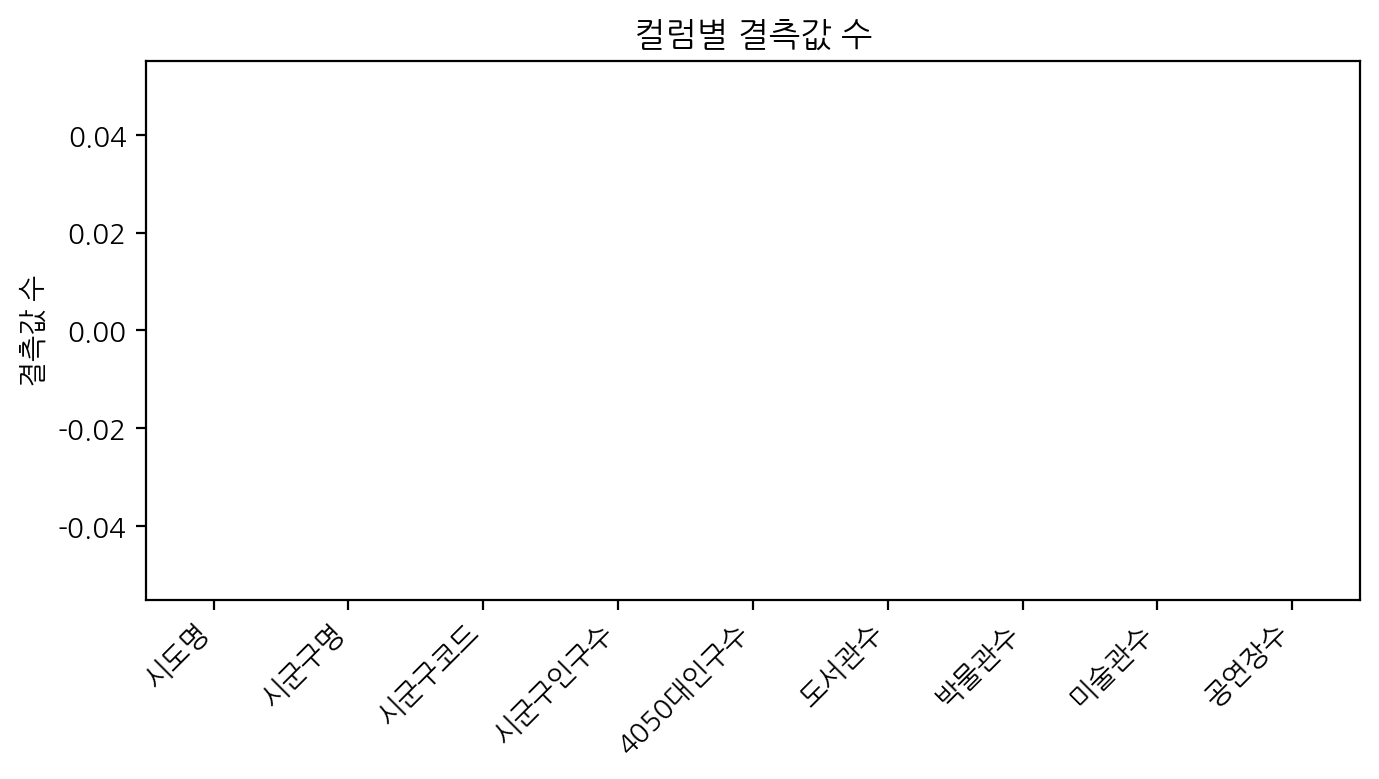

In [ ]:
# 시각화 1: 결측값
missing_report["결측값수"].plot(kind="bar", figsize=(7, 4), title="컬럼별 결측값 수")
plt.xticks(rotation=45, ha="right")
plt.ylabel("결측값 수")
plt.tight_layout()
plt.show()

In [ ]:
analysis = df.dropna(subset=["시도명", "시군구명", "4050대인구수", "도서관수", "박물관수", "미술관수", "공연장수"]).copy()
analysis = analysis[analysis["4050대인구수"] > 0].copy()
analysis["시군구인구수"] = analysis["시군구인구수"].where(analysis["시군구인구수"] > 0, np.nan)

print("전처리 전:", df.shape)
print("분석 데이터:", analysis.shape)
print("중복 행:", analysis.duplicated(subset=["시도명", "시군구명", "시군구코드"]).sum())

전처리 전: (252, 15)
분석 데이터: (252, 15)
중복 행: 0


## 4. 핵심 지표 설계

In [ ]:
facility_cols = ["도서관수", "박물관수", "미술관수", "공연장수"]

analysis["문화시설수"] = analysis[facility_cols].sum(axis=1)
analysis["4050인구비중"] = analysis["4050대인구수"] / analysis["시군구인구수"]

for col in facility_cols + ["문화시설수"]:
    analysis[col.replace("수", "접근도")] = analysis[col] / analysis["4050대인구수"] * 10000

access_cols = ["도서관접근도", "박물관접근도", "미술관접근도", "공연장접근도"]

facility_sum = analysis[facility_cols].sum(axis=1).replace(0, np.nan)
shares = analysis[facility_cols].div(facility_sum, axis=0).fillna(0)
analysis["시설다양성지수"] = -(shares * np.log(shares.replace(0, np.nan))).sum(axis=1).fillna(0)
analysis["시설다양성점수"] = minmax(analysis["시설다양성지수"]) * 100

for col in access_cols:
    std = analysis[col].std()
    analysis[col + "_z"] = 0 if std == 0 else (analysis[col] - analysis[col].mean()) / std

z_cols = [c + "_z" for c in access_cols]
analysis["접근도_z평균"] = analysis[z_cols].mean(axis=1)
analysis["접근도점수"] = minmax(analysis["접근도_z평균"]) * 100

analysis["문화접근성점수"] = (
    0.70 * analysis["접근도점수"] +
    0.20 * analysis["시설다양성점수"] +
    0.10 * minmax(analysis["문화시설수"]) * 100
)

analysis[["시도명", "시군구명", "4050대인구수", "문화시설수", "문화시설접근도", "시설다양성점수", "문화접근성점수"]].head()

,시도명,시군구명,4050대인구수,문화시설수,문화시설접근도,시설다양성점수,문화접근성점수
0,서울특별시,종로구,54824,387,70.590,45.176,89.035
1,서울특별시,중구,50061,103,20.575,62.157,37.869
2,서울특별시,용산구,86032,82,9.531,50.875,21.651
3,서울특별시,성동구,92116,67,7.273,43.504,17.589
4,서울특별시,광진구,110318,41,3.717,51.466,15.008


In [ ]:
analysis["4050인구순위"] = analysis["4050대인구수"].rank(ascending=False, method="min")
analysis["접근성순위"] = analysis["문화접근성점수"].rank(ascending=False, method="min")
analysis["수요공급격차"] = analysis["접근성순위"] - analysis["4050인구순위"]

for col in access_cols:
    analysis[col + "_부족"] = analysis[col] < analysis[col].median()

lack_cols = [col + "_부족" for col in access_cols]
analysis["부족유형수"] = analysis[lack_cols].sum(axis=1)

def lack_label(row):
    labels = []
    if row["도서관접근도_부족"]:
        labels.append("도서관")
    if row["박물관접근도_부족"]:
        labels.append("박물관")
    if row["미술관접근도_부족"]:
        labels.append("미술관")
    if row["공연장접근도_부족"]:
        labels.append("공연장")
    return ",".join(labels) if labels else "상대적 부족 없음"

analysis["부족시설유형"] = analysis.apply(lack_label, axis=1)
analysis[["시도명", "시군구명", "문화접근성점수", "수요공급격차", "부족시설유형"]].head()

,시도명,시군구명,문화접근성점수,수요공급격차,부족시설유형
0,서울특별시,종로구,89.035,-128.000,상대적 부족 없음
1,서울특별시,중구,37.869,-118.000,상대적 부족 없음
2,서울특별시,용산구,21.651,35.000,도서관
3,서울특별시,성동구,17.589,111.000,"도서관,박물관"
4,서울특별시,광진구,15.008,159.000,"도서관,박물관,미술관"


## 5. 전체 현황과 다양한 시각화

In [ ]:
total_summary = pd.DataFrame({
    "항목": ["분석 지역 수", "4050 인구 합계", "문화시설 합계", "도서관 수", "박물관 수", "미술관 수", "공연장 수"],
    "값": [
        len(analysis),
        analysis["4050대인구수"].sum(),
        analysis["문화시설수"].sum(),
        analysis["도서관수"].sum(),
        analysis["박물관수"].sum(),
        analysis["미술관수"].sum(),
        analysis["공연장수"].sum()
    ]
})
total_summary["값"] = total_summary["값"].apply(format_int)
total_summary

,항목,값
0,분석 지역 수,252
1,4050 인구 합계,"16,781,806"
2,문화시설 합계,"5,738"
3,도서관 수,"1,194"
4,박물관 수,897
5,미술관 수,286
6,공연장 수,"3,361"


In [ ]:
analysis[["4050대인구수", "문화시설수", "문화시설접근도", "문화접근성점수", "시설다양성점수", "수요공급격차"]].describe()

,4050대인구수,문화시설수,문화시설접근도,문화접근성점수,시설다양성점수,수요공급격차
count,252.000,252.000,252.000,252.000,252.000,252.000
mean,"66,594.468",22.770,5.432,23.191,72.157,0.000
std,"58,021.455",33.943,6.245,10.246,16.882,131.408
min,"1,934.000",1.000,0.492,6.717,0.000,-243.000
25%,"14,927.750",9.000,1.935,16.818,64.776,-120.250
50%,"56,168.500",14.500,3.618,21.104,75.216,7.500
75%,"101,085.750",25.250,7.095,26.545,83.439,114.000
max,"348,863.000",387.000,70.590,89.035,100.000,218.000


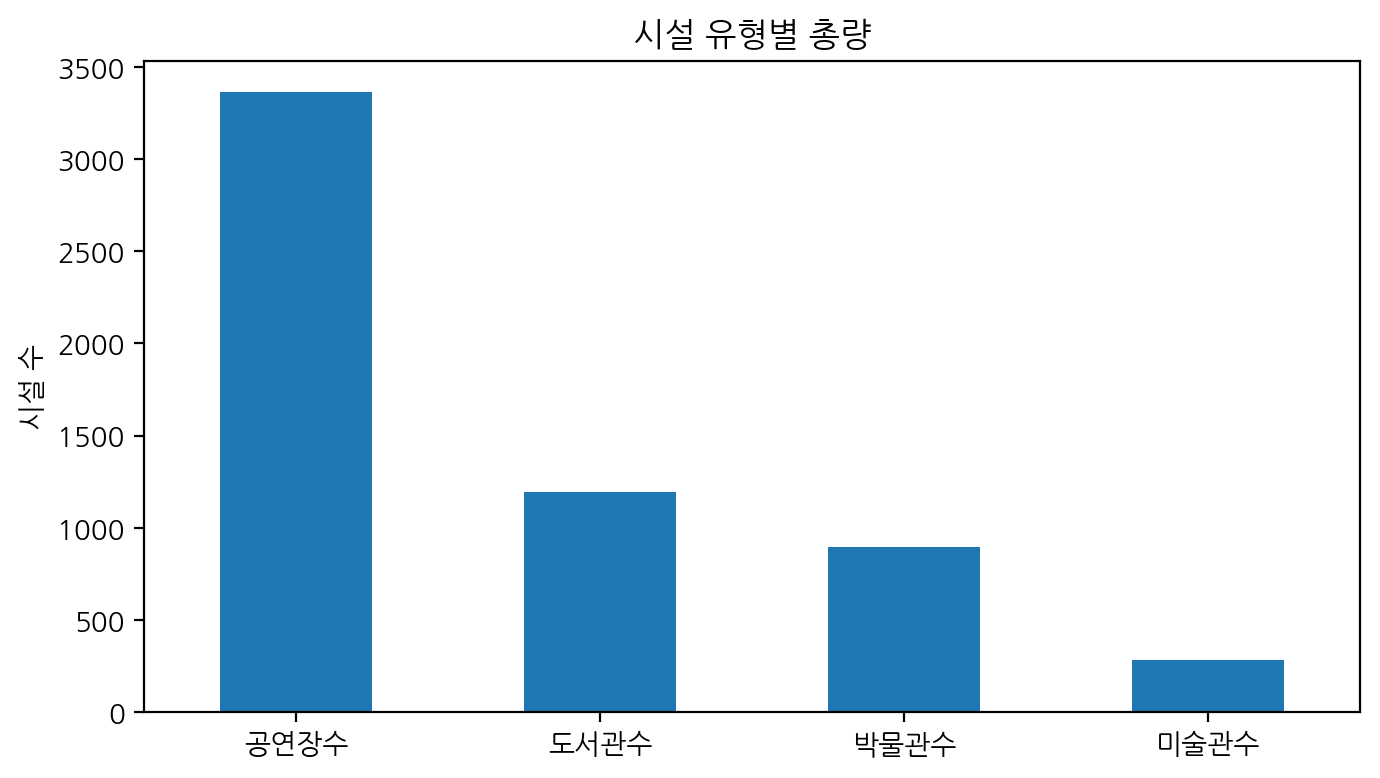

In [ ]:
# 시각화 2: 시설 유형별 총량
facility_total = analysis[facility_cols].sum().sort_values(ascending=False)
facility_total.plot(kind="bar", title="시설 유형별 총량", figsize=(7, 4))
plt.xticks(rotation=0)
plt.ylabel("시설 수")
plt.tight_layout()
plt.show()

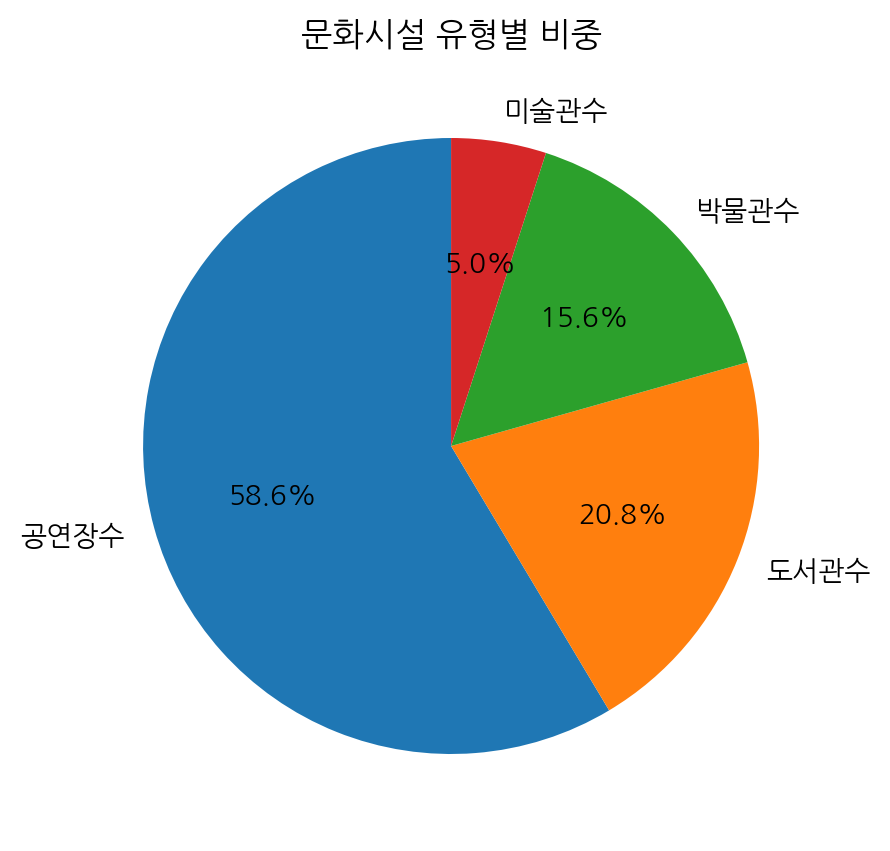

In [ ]:
# 시각화 3: 시설 유형별 비중
plt.figure(figsize=(5, 5))
plt.pie(facility_total, labels=facility_total.index, autopct="%.1f%%", startangle=90)
plt.title("문화시설 유형별 비중")
plt.show()

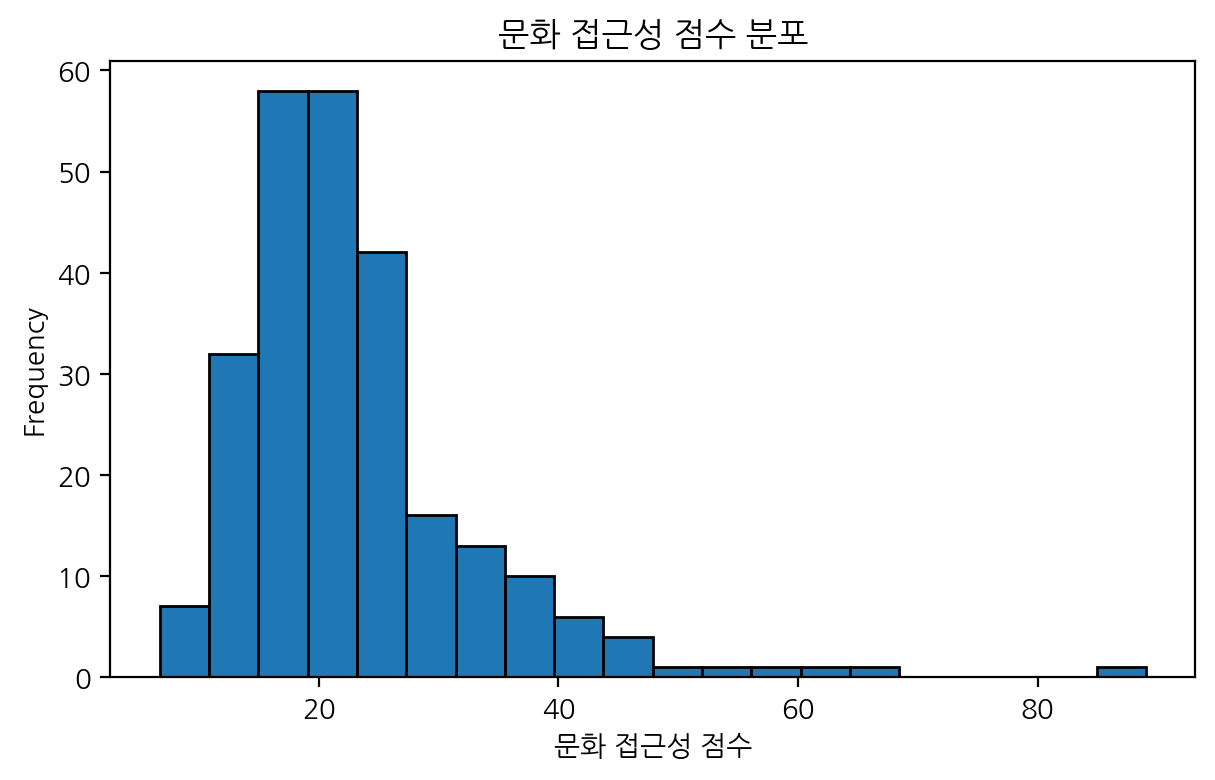

In [ ]:
# 시각화 4: 문화 접근성 점수 분포
analysis["문화접근성점수"].plot(kind="hist", bins=20, edgecolor="black", title="문화 접근성 점수 분포")
plt.xlabel("문화 접근성 점수")
plt.show()

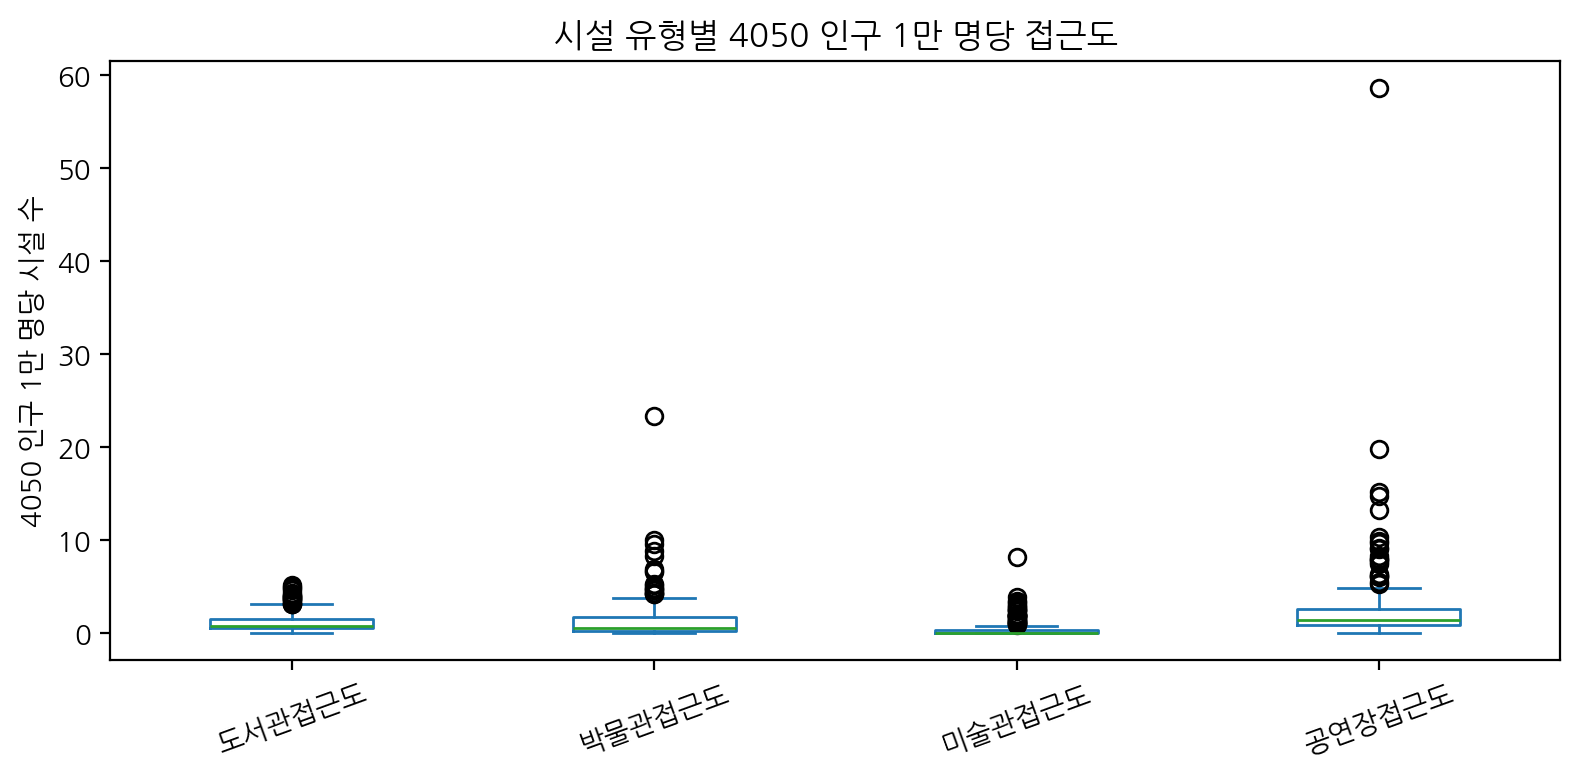

In [ ]:
# 시각화 5: 시설 유형별 접근도 박스플롯
analysis[access_cols].plot(kind="box", figsize=(8, 4), title="시설 유형별 4050 인구 1만 명당 접근도")
plt.ylabel("4050 인구 1만 명당 시설 수")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

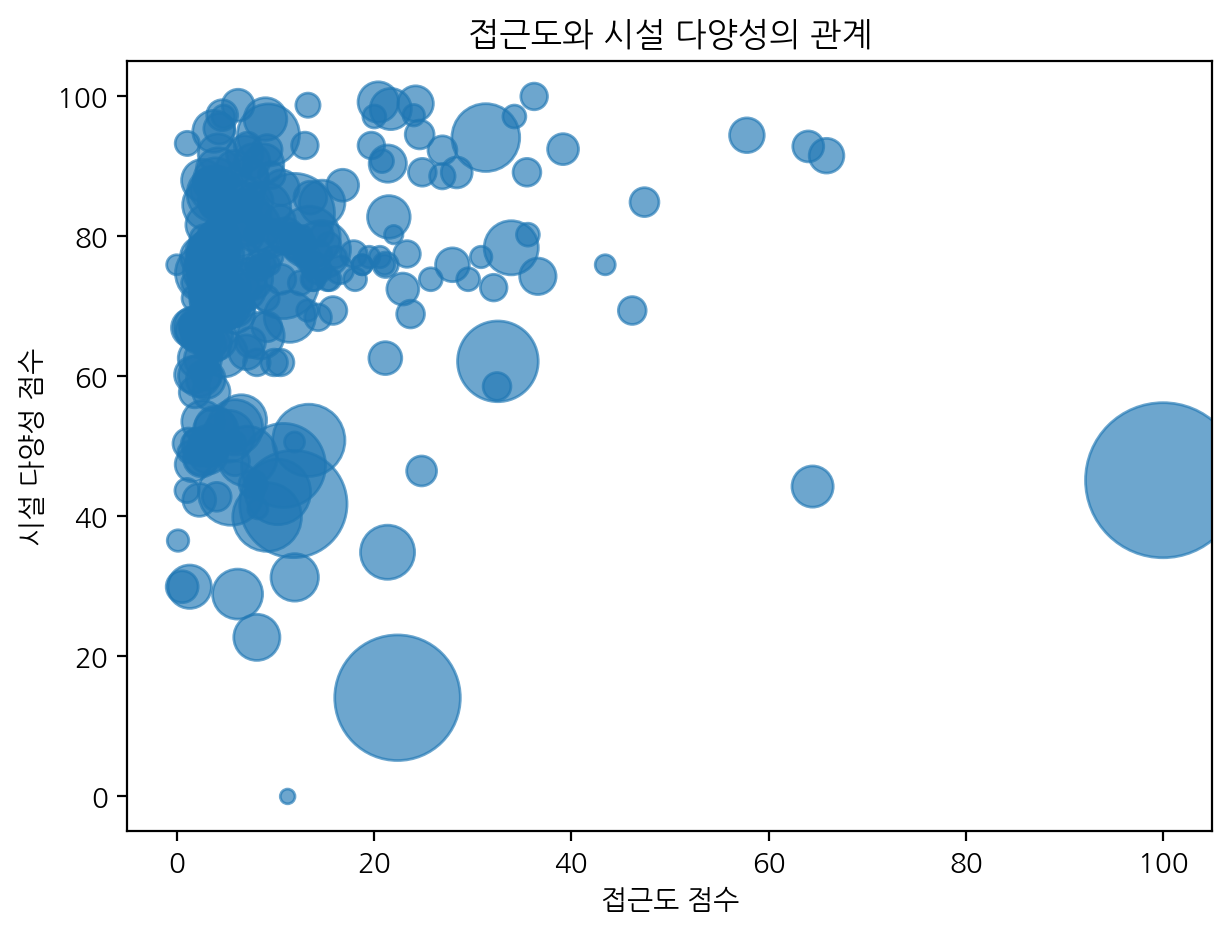

In [ ]:
# 시각화 6: 접근도와 시설 다양성 산점도
plt.figure(figsize=(7, 5))
plt.scatter(analysis["접근도점수"], analysis["시설다양성점수"], s=analysis["문화시설수"] * 8 + 20, alpha=0.65)
plt.xlabel("접근도 점수")
plt.ylabel("시설 다양성 점수")
plt.title("접근도와 시설 다양성의 관계")
plt.show()

## 6. 시도별 문화 접근성 비교

In [ ]:
sido = analysis.groupby("시도명", as_index=False).agg(
    지역수=("시군구명", "count"),
    총인구=("시군구인구수", "sum"),
    대상인구_4050=("4050대인구수", "sum"),
    도서관수=("도서관수", "sum"),
    박물관수=("박물관수", "sum"),
    미술관수=("미술관수", "sum"),
    공연장수=("공연장수", "sum"),
    평균문화접근성=("문화접근성점수", "mean"),
    평균시설다양성=("시설다양성점수", "mean")
)

sido["문화시설수"] = sido[facility_cols].sum(axis=1)
sido["4050_1만명당시설수"] = sido["문화시설수"] / sido["대상인구_4050"] * 10000
sido["4050인구비중"] = sido["대상인구_4050"] / sido["총인구"]

sido.sort_values("4050_1만명당시설수", ascending=False)

,시도명,지역수,총인구,대상인구_4050,도서관수,박물관수,미술관수,공연장수,평균문화접근성,평균시설다양성,문화시설수,4050_1만명당시설수,4050인구비중
14,제주특별자치도,2,565601,219959,22,61,19,72,35.111,88.697,174,7.911,0.389
0,강원특별자치도,18,1240327,431353,65,99,18,151,35.549,77.691,333,7.720,0.348
8,서울특별시,25,9041955,3150884,212,132,50,1401,20.951,56.606,1795,5.697,0.348
12,전라남도,22,1459772,509978,74,64,40,84,33.618,84.067,262,5.137,0.349
3,경상북도,23,2163326,775996,71,70,12,126,25.743,78.852,279,3.595,0.359
15,충청남도,16,1861686,685821,62,64,10,100,23.723,76.645,236,3.441,0.368
16,충청북도,14,1389433,507555,55,38,11,68,24.059,79.040,172,3.389,0.365
13,전북특별자치도,15,1473654,521059,2,42,20,110,19.924,64.613,174,3.339,0.354
7,부산광역시,16,2775471,969439,53,33,9,207,17.671,65.231,302,3.115,0.349
6,대전광역시,5,1286793,461975,25,15,5,96,16.859,63.188,141,3.052,0.359


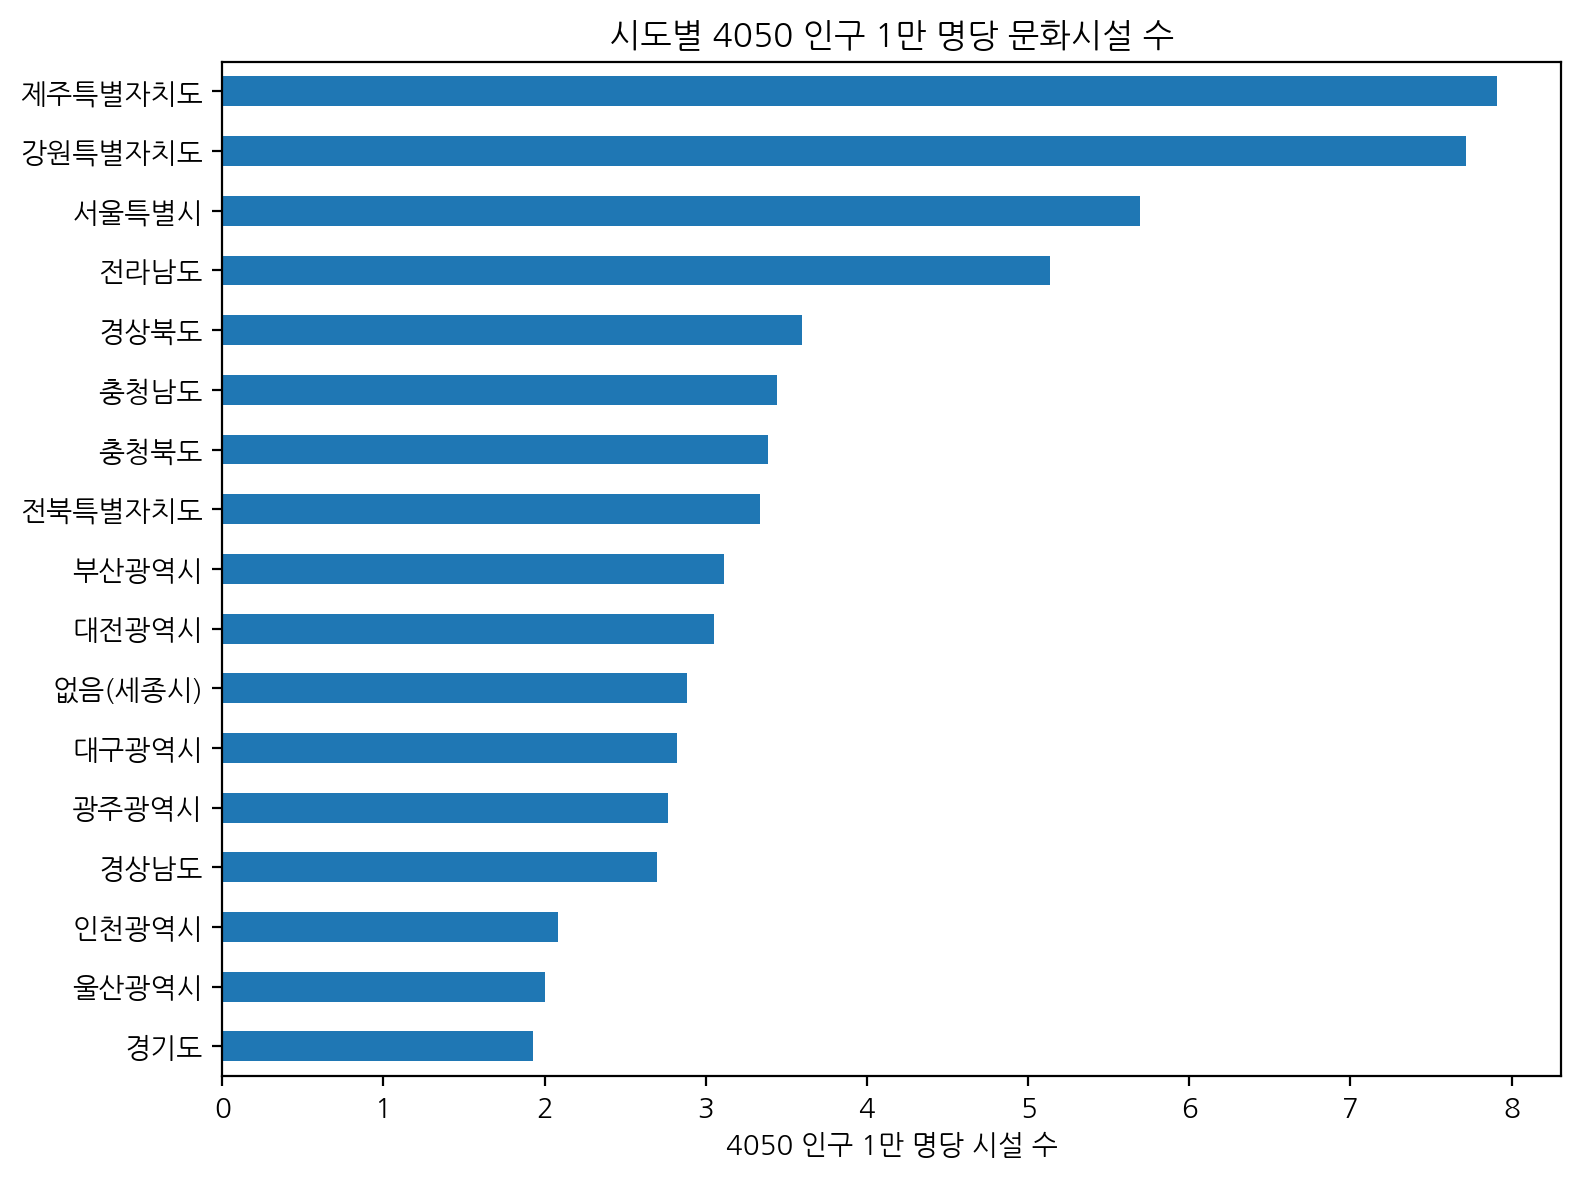

In [ ]:
# 시각화 7: 시도별 4050 인구 1만 명당 시설 수
sido.sort_values("4050_1만명당시설수").plot(
    x="시도명", y="4050_1만명당시설수", kind="barh", figsize=(8, 6),
    title="시도별 4050 인구 1만 명당 문화시설 수", legend=False
)
plt.xlabel("4050 인구 1만 명당 시설 수")
plt.ylabel("")
plt.tight_layout()
plt.show()

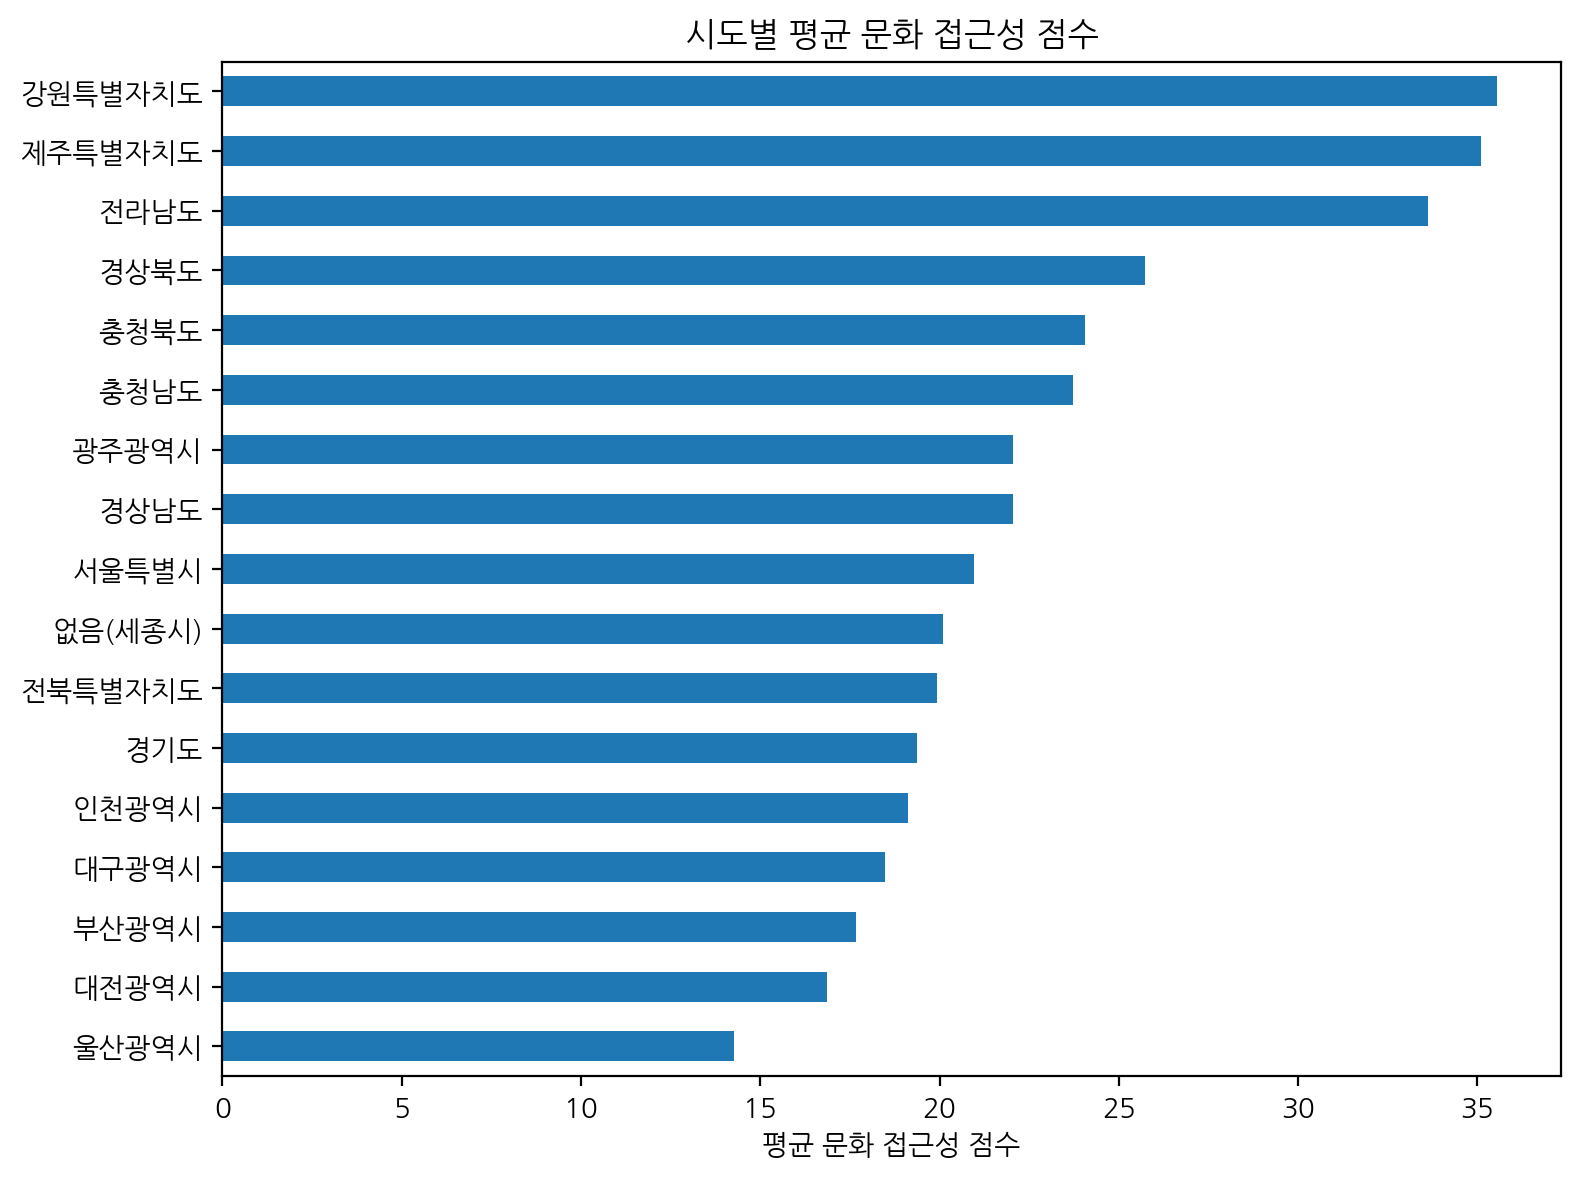

In [ ]:
# 시각화 8: 시도별 평균 문화 접근성 점수
sido.sort_values("평균문화접근성").plot(
    x="시도명", y="평균문화접근성", kind="barh", figsize=(8, 6),
    title="시도별 평균 문화 접근성 점수", legend=False
)
plt.xlabel("평균 문화 접근성 점수")
plt.ylabel("")
plt.tight_layout()
plt.show()

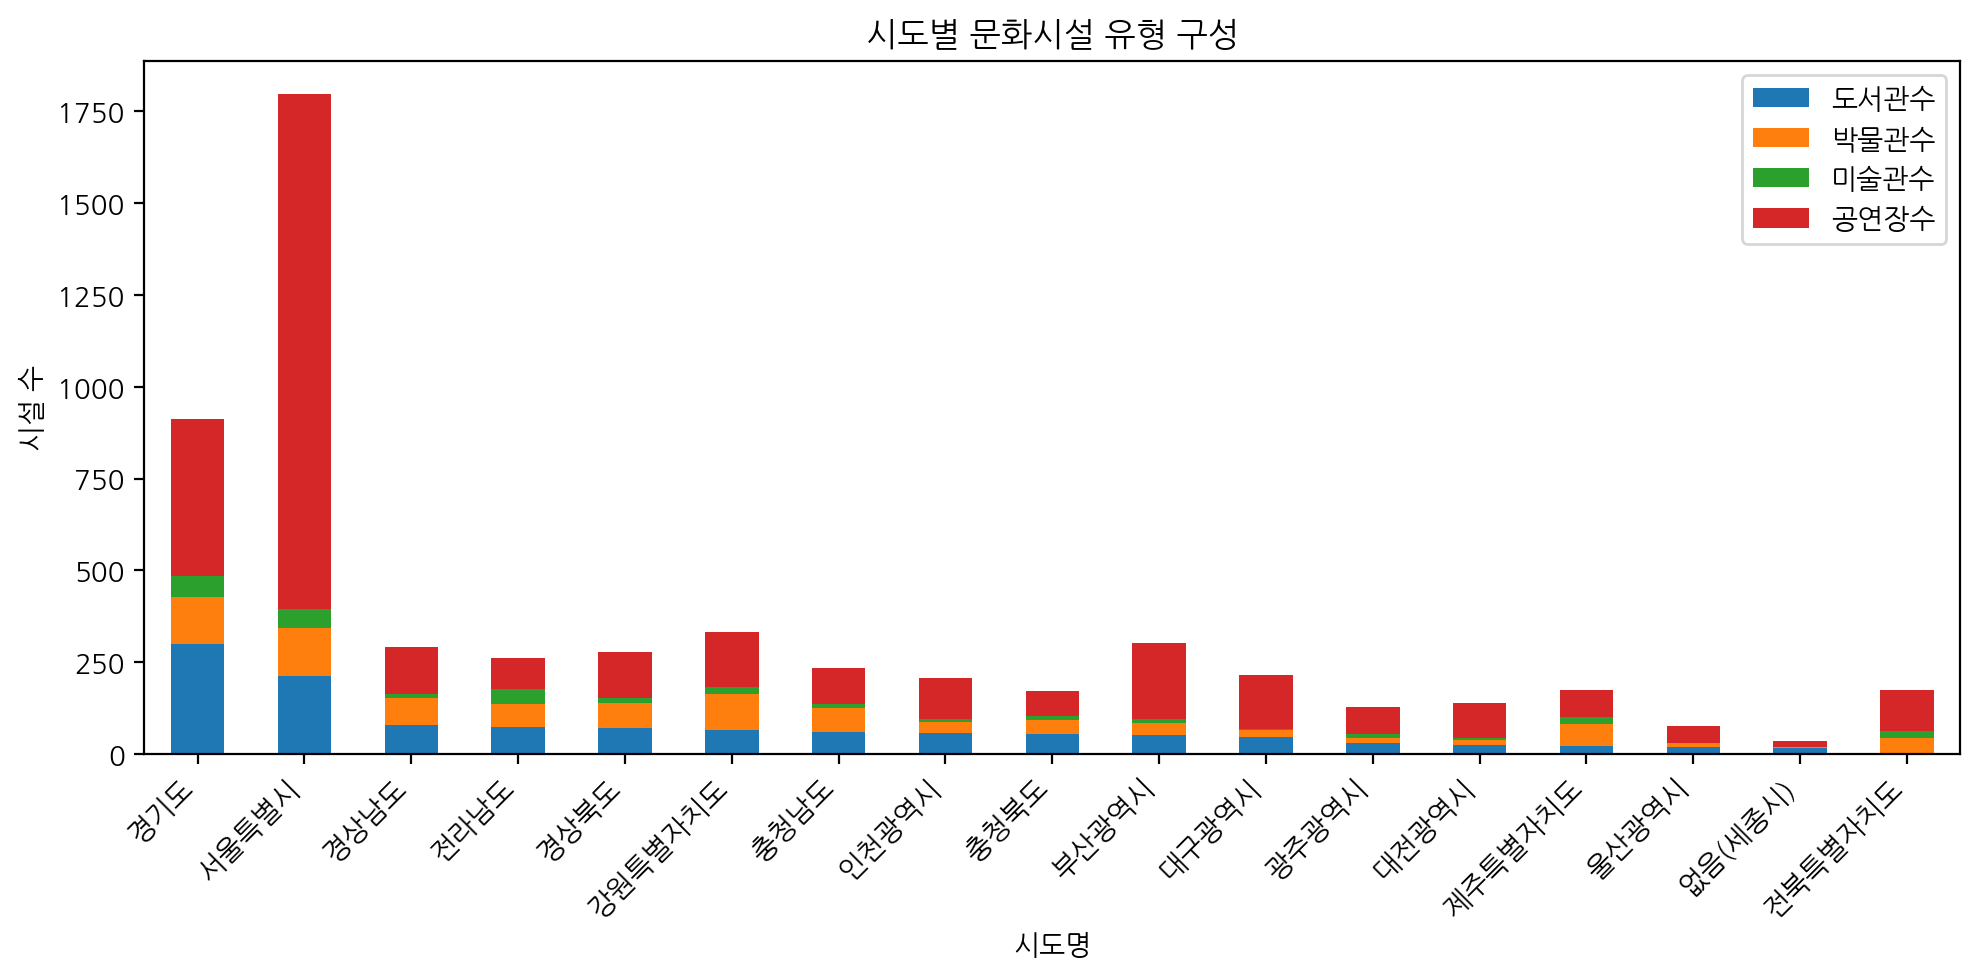

In [ ]:
# 시각화 9: 시도별 시설 유형 누적 막대
sido_facility = sido.set_index("시도명")[facility_cols].sort_values("도서관수", ascending=False)
sido_facility.plot(kind="bar", stacked=True, figsize=(10, 5), title="시도별 문화시설 유형 구성")
plt.ylabel("시설 수")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

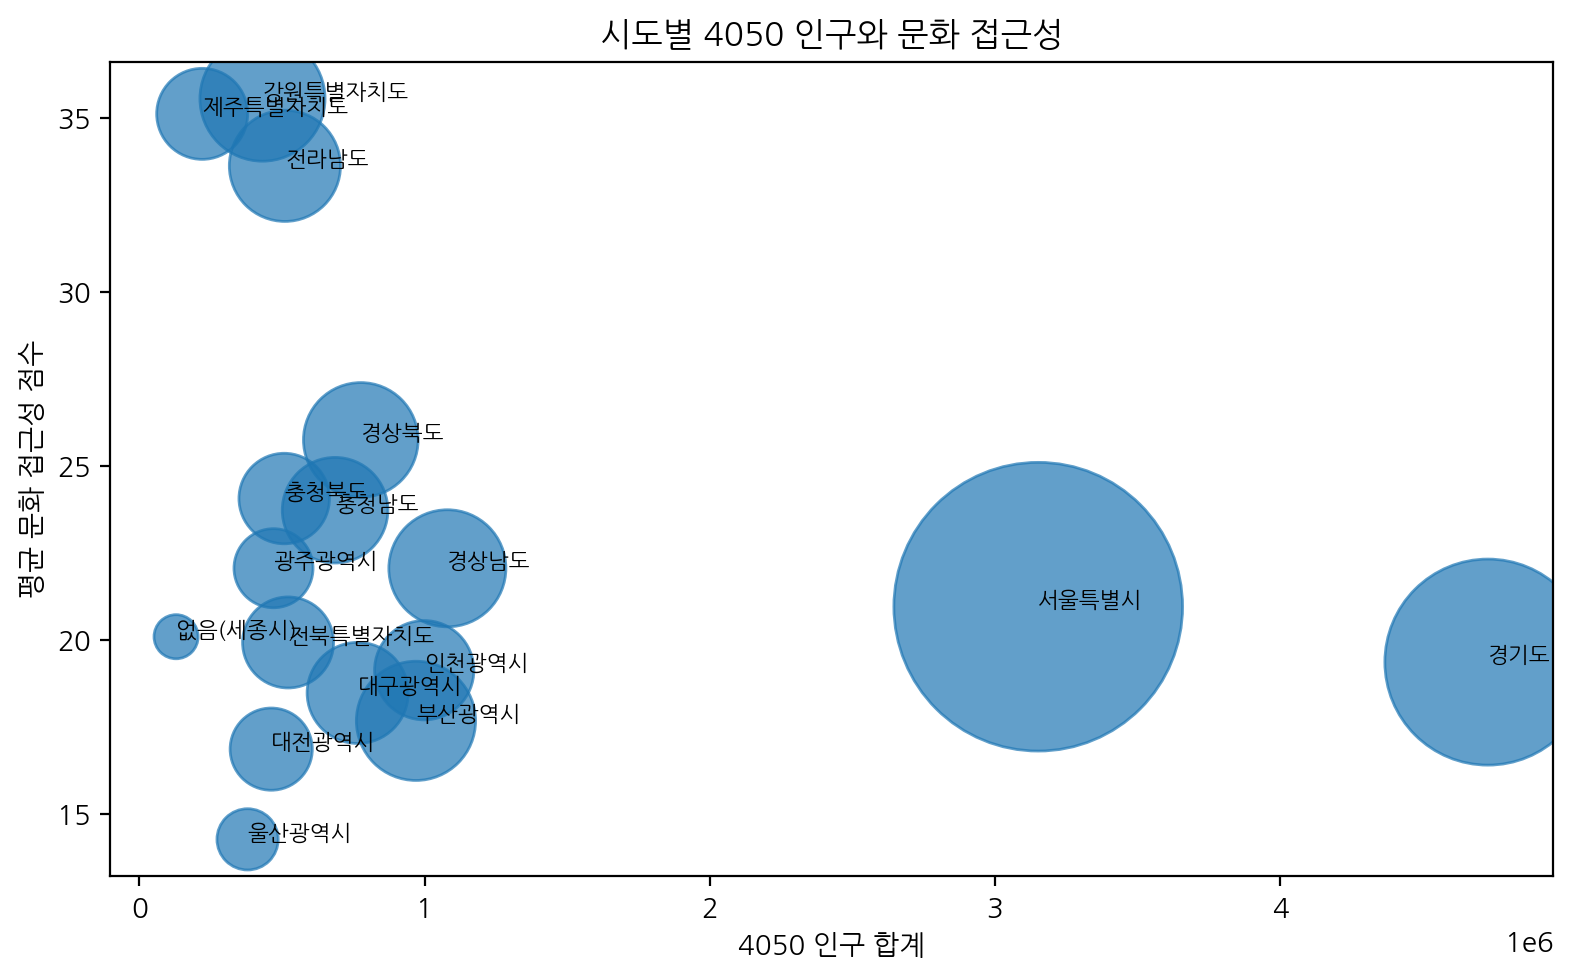

In [ ]:
# 시각화 10: 시도별 4050 인구와 문화 접근성
plt.figure(figsize=(8, 5))
plt.scatter(sido["대상인구_4050"], sido["평균문화접근성"], s=sido["문화시설수"] * 6 + 30, alpha=0.7)
for _, r in sido.iterrows():
    plt.text(r["대상인구_4050"], r["평균문화접근성"], r["시도명"], fontsize=8)
plt.xlabel("4050 인구 합계")
plt.ylabel("평균 문화 접근성 점수")
plt.title("시도별 4050 인구와 문화 접근성")
plt.tight_layout()
plt.show()

## 7. 접근성 상위·하위 지역과 수요-공급 격차

In [ ]:
top_access = analysis.sort_values("문화접근성점수", ascending=False).head(15)
bottom_access = analysis.sort_values("문화접근성점수", ascending=True).head(15)

show_tables(
    top_access[["시도명", "시군구명", "4050대인구수", "문화시설수", "문화시설접근도", "문화접근성점수"]],
    bottom_access[["시도명", "시군구명", "4050대인구수", "문화시설수", "문화시설접근도", "문화접근성점수", "부족시설유형"]],
    titles=["접근성 상위", "접근성 하위"]
)

,시도명,시군구명,4050대인구수,문화시설수,문화시설접근도,문화접근성점수
0,서울특별시,종로구,54824,387,70.590,89.035
235,강원특별자치도,고성군,6065,17,28.030,64.840
170,전라남도,진도군,7379,13,17.618,63.705
234,강원특별자치도,인제군,7249,17,23.452,59.773
228,강원특별자치도,영월군,8985,25,27.824,54.605
233,강원특별자치도,양구군,5014,11,21.939,50.437
171,전라남도,신안군,6769,10,14.773,46.447
158,전라남도,고흥군,12829,13,10.133,46.225
194,경상북도,울릉군,1934,4,20.683,45.681
159,전라남도,보성군,8096,9,11.117,45.577


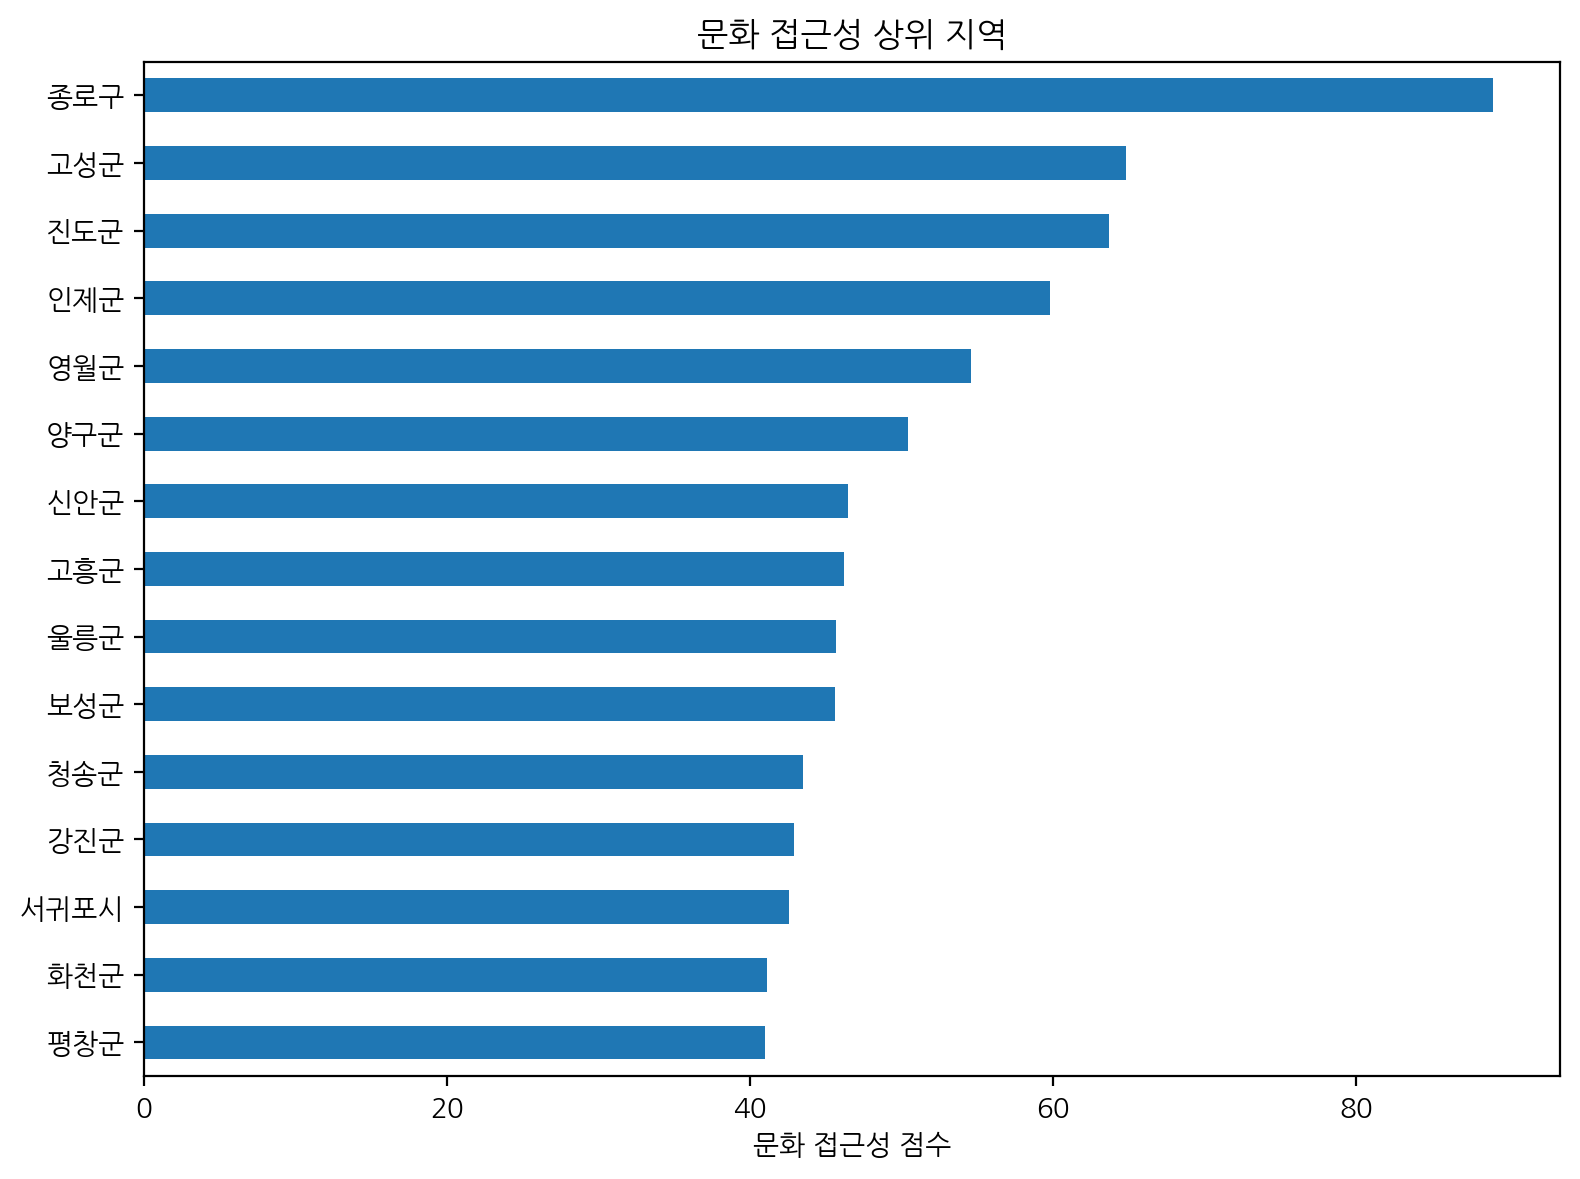

In [ ]:
# 시각화 11: 접근성 상위 지역
top_access.sort_values("문화접근성점수").plot(
    x="시군구명", y="문화접근성점수", kind="barh", figsize=(8, 6),
    title="문화 접근성 상위 지역", legend=False
)
plt.xlabel("문화 접근성 점수")
plt.ylabel("")
plt.tight_layout()
plt.show()

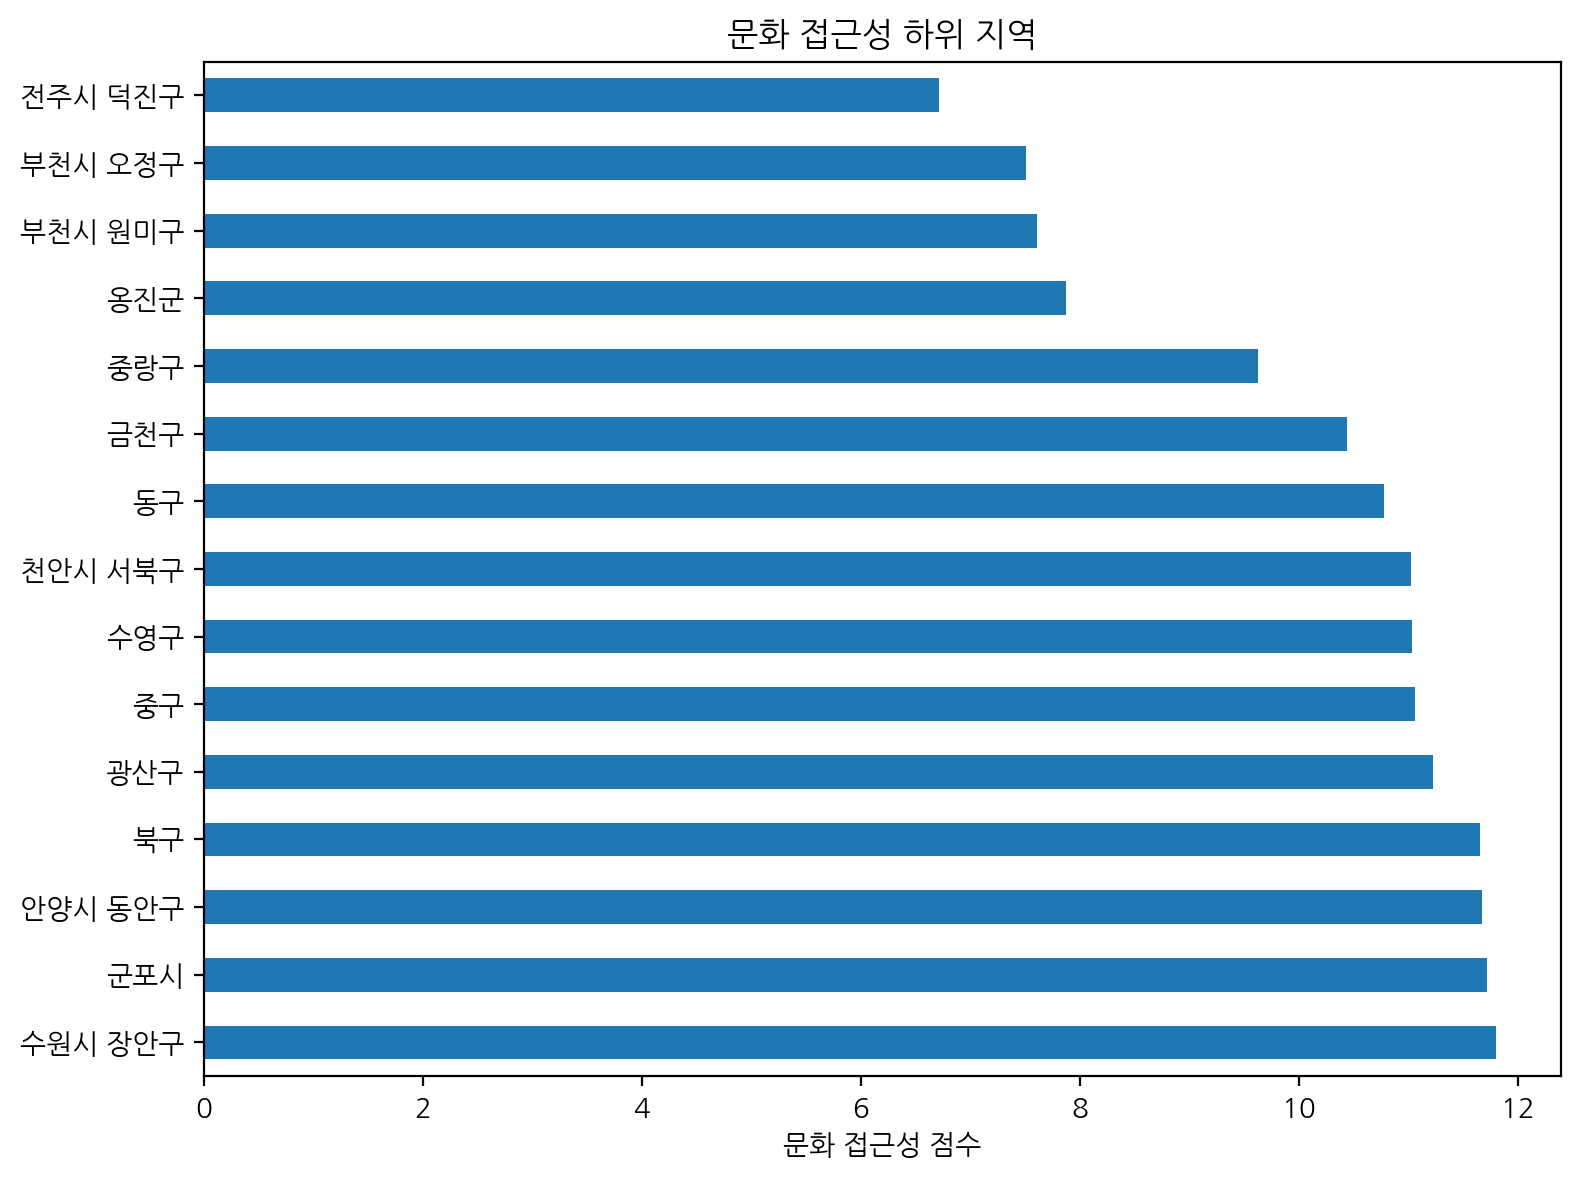

In [ ]:
# 시각화 12: 접근성 하위 지역
bottom_access.sort_values("문화접근성점수", ascending=False).plot(
    x="시군구명", y="문화접근성점수", kind="barh", figsize=(8, 6),
    title="문화 접근성 하위 지역", legend=False
)
plt.xlabel("문화 접근성 점수")
plt.ylabel("")
plt.tight_layout()
plt.show()

In [ ]:
gap_rank = analysis.sort_values("수요공급격차", ascending=False).head(20)
gap_rank[["시도명", "시군구명", "4050대인구수", "문화시설수", "문화접근성점수", "4050인구순위", "접근성순위", "수요공급격차", "부족시설유형"]]

,시도명,시군구명,4050대인구수,문화시설수,문화접근성점수,4050인구순위,접근성순위,수요공급격차,부족시설유형
64,광주광역시,광산구,150916,13,11.230,24.000,242.000,218.000,"도서관,박물관,미술관,공연장"
90,경기도,평택시,204212,26,14.283,7.000,223.000,216.000,"도서관,박물관,미술관,공연장"
86,경기도,부천시 원미구,140290,28,7.612,34.000,250.000,216.000,"도서관,박물관,미술관"
135,충청남도,천안시 서북구,143138,17,11.024,30.000,245.000,215.000,"도서관,박물관,미술관,공연장"
14,서울특별시,양천구,146830,25,12.930,27.000,233.000,206.000,"도서관,박물관,미술관,공연장"
83,경기도,의정부시,149054,26,13.210,26.000,231.000,205.000,"도서관,박물관,공연장"
54,인천광역시,남동구,170896,21,14.889,12.000,215.000,203.000,"도서관,박물관,미술관,공연장"
57,인천광역시,서구,203958,23,15.201,8.000,210.000,202.000,"도서관,박물관,미술관,공연장"
18,서울특별시,영등포구,152398,66,14.210,22.000,224.000,202.000,"도서관,박물관"
55,인천광역시,부평구,166738,21,15.078,14.000,212.000,198.000,"도서관,박물관,미술관,공연장"


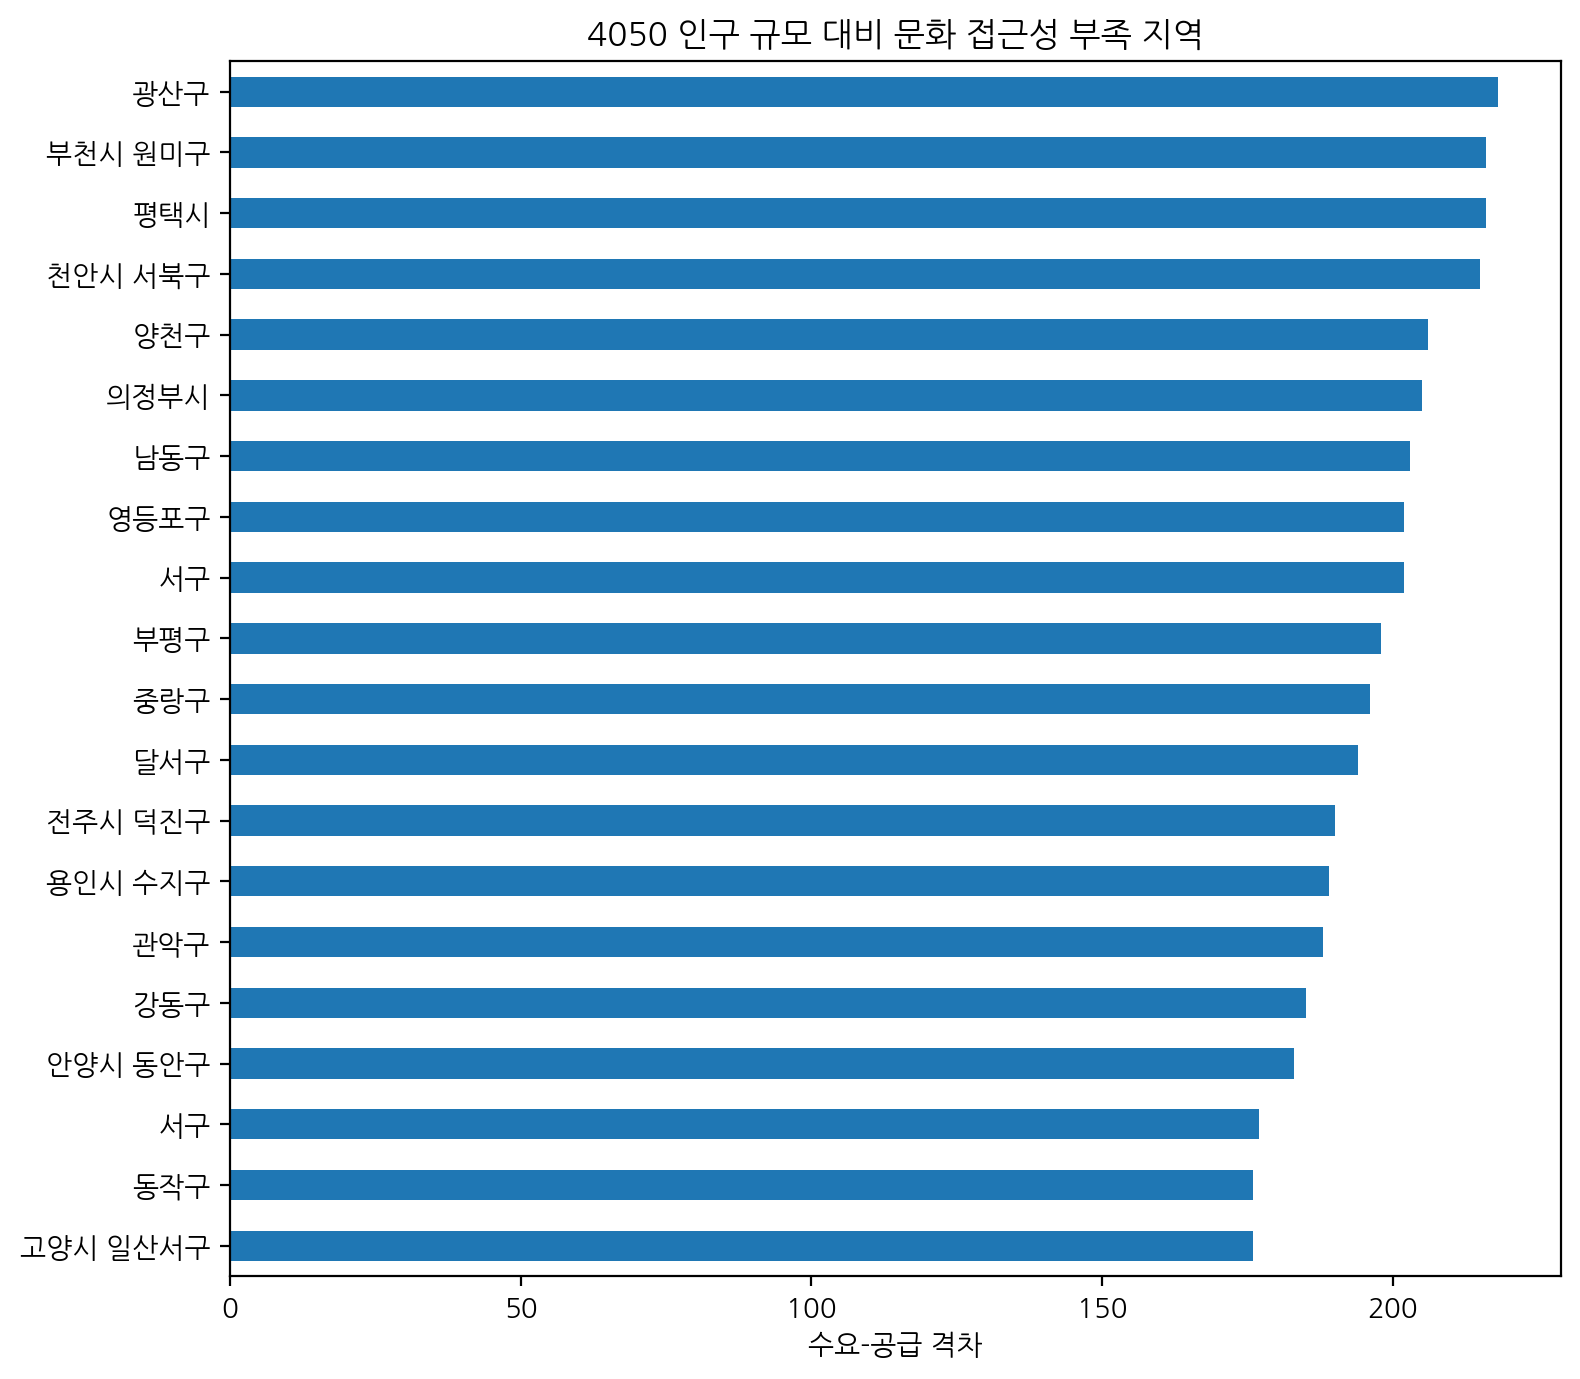

In [ ]:
# 시각화 13: 수요-공급 격차 상위 지역
gap_rank.sort_values("수요공급격차").plot(
    x="시군구명", y="수요공급격차", kind="barh", figsize=(8, 7),
    title="4050 인구 규모 대비 문화 접근성 부족 지역", legend=False
)
plt.xlabel("수요-공급 격차")
plt.ylabel("")
plt.tight_layout()
plt.show()

## 8. 시설 유형별 부족 진단

In [ ]:
lack_count = analysis["부족시설유형"].value_counts()
lack_count.head(20)

,count
부족시설유형,
"도서관,박물관,미술관,공연장",44
상대적 부족 없음,32
미술관,29
"도서관,박물관,공연장",23
"미술관,공연장",17
도서관,17
"도서관,박물관",15
공연장,12
"박물관,미술관,공연장",11


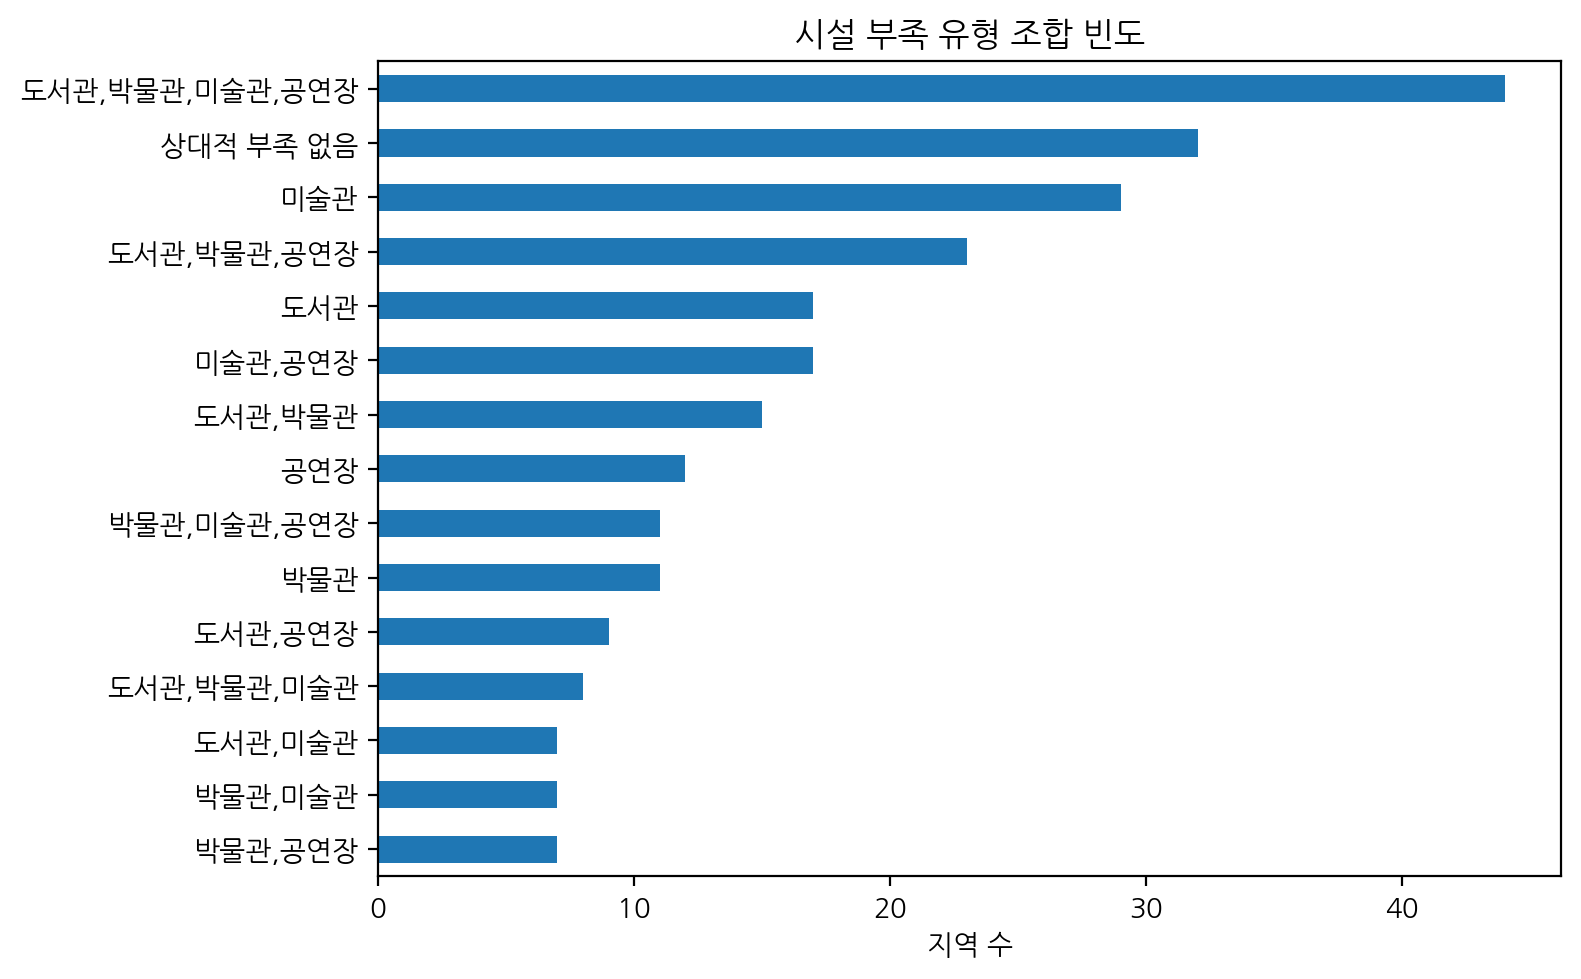

In [ ]:
# 시각화 14: 부족 시설 유형 빈도
lack_count.head(15).sort_values().plot(kind="barh", figsize=(8, 5), title="시설 부족 유형 조합 빈도")
plt.xlabel("지역 수")
plt.ylabel("")
plt.tight_layout()
plt.show()

In [ ]:
q25 = analysis["문화접근성점수"].quantile(0.25)
weak = analysis[(analysis["문화접근성점수"] <= q25) | (analysis["부족유형수"] >= 3)].copy()

weak[["시도명", "시군구명", "4050대인구수", "문화접근성점수", "부족시설유형", "부족유형수"]].sort_values(
    ["부족유형수", "문화접근성점수"], ascending=[False, True]
).head(30)

,시도명,시군구명,4050대인구수,문화접근성점수,부족시설유형,부족유형수
238,전북특별자치도,전주시 덕진구,103226,6.717,"도서관,박물관,미술관,공연장",4
88,경기도,부천시 오정구,52289,7.510,"도서관,박물관,미술관,공연장",4
6,서울특별시,중랑구,115445,9.630,"도서관,박물관,미술관,공연장",4
17,서울특별시,금천구,87286,10.440,"도서관,박물관,미술관,공연장",4
72,울산광역시,동구,52997,10.783,"도서관,박물관,미술관,공연장",4
135,충청남도,천안시 서북구,143138,11.024,"도서관,박물관,미술관,공연장",4
64,광주광역시,광산구,150916,11.230,"도서관,박물관,미술관,공연장",4
85,경기도,안양시 동안구,106906,11.673,"도서관,박물관,미술관,공연장",4
102,경기도,군포시,90145,11.721,"도서관,박물관,미술관,공연장",4
76,경기도,수원시 장안구,87932,11.804,"도서관,박물관,미술관,공연장",4


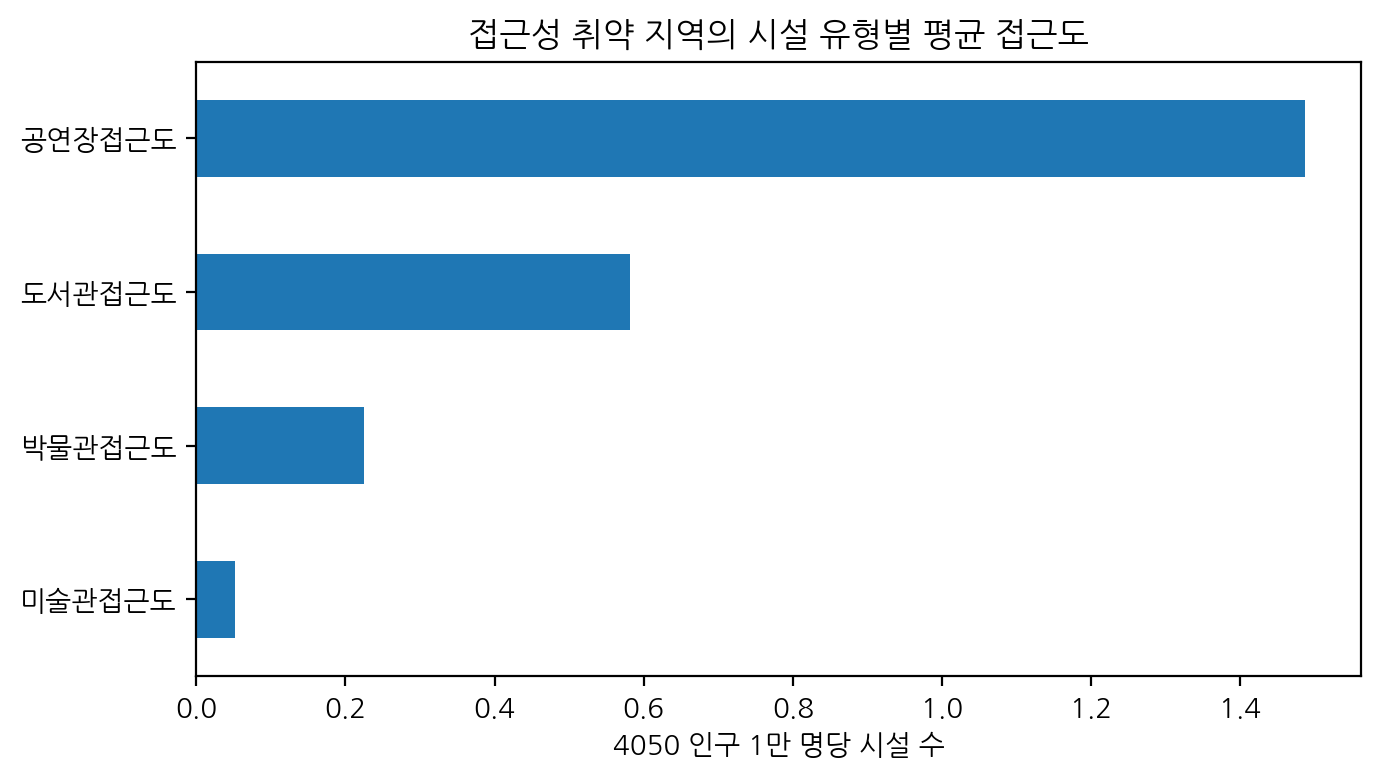

In [ ]:
# 시각화 15: 접근성 취약 지역의 시설 유형별 평균 접근도
weak_access_mean = weak[access_cols].mean().sort_values()
weak_access_mean.plot(kind="barh", figsize=(7, 4), title="접근성 취약 지역의 시설 유형별 평균 접근도")
plt.xlabel("4050 인구 1만 명당 시설 수")
plt.ylabel("")
plt.tight_layout()
plt.show()

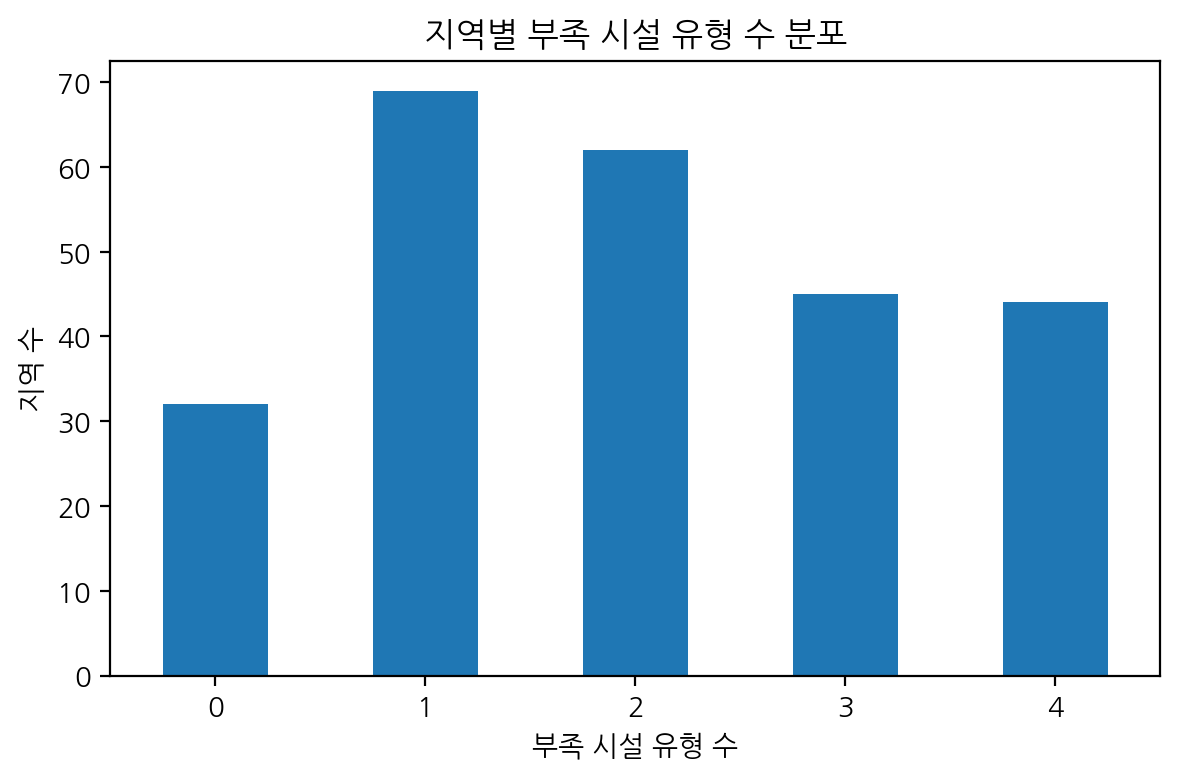

In [ ]:
# 시각화 16: 부족유형수 분포
analysis["부족유형수"].value_counts().sort_index().plot(kind="bar", figsize=(6, 4), title="지역별 부족 시설 유형 수 분포")
plt.xlabel("부족 시설 유형 수")
plt.ylabel("지역 수")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 9. 상관관계 분석과 관계 시각화

In [ ]:
corr_cols = [
    "4050대인구수", "문화시설수", "도서관수", "박물관수", "미술관수", "공연장수",
    "도서관접근도", "박물관접근도", "미술관접근도", "공연장접근도",
    "문화시설접근도", "시설다양성점수", "문화접근성점수"
]
corr = analysis[corr_cols].corr()
corr

,4050대인구수,문화시설수,도서관수,박물관수,미술관수,공연장수,도서관접근도,박물관접근도,미술관접근도,공연장접근도,문화시설접근도,시설다양성점수,문화접근성점수
4050대인구수,1.000,0.336,0.770,0.114,0.128,0.276,-0.542,-0.418,-0.294,-0.135,-0.371,-0.169,-0.460
문화시설수,0.336,1.000,0.422,0.622,0.644,0.982,-0.134,0.047,0.118,0.770,0.551,-0.267,0.248
도서관수,0.770,0.422,1.000,0.297,0.291,0.310,-0.176,-0.265,-0.163,-0.006,-0.148,0.041,-0.140
박물관수,0.114,0.622,0.297,1.000,0.669,0.493,0.012,0.437,0.191,0.474,0.515,0.136,0.446
미술관수,0.128,0.644,0.291,0.669,1.000,0.549,0.005,0.147,0.541,0.555,0.517,0.212,0.514
공연장수,0.276,0.982,0.310,0.493,0.549,1.000,-0.138,0.008,0.092,0.793,0.550,-0.353,0.204
도서관접근도,-0.542,-0.134,-0.176,0.012,0.005,-0.138,1.000,0.460,0.328,0.198,0.510,0.244,0.688
박물관접근도,-0.418,0.047,-0.265,0.437,0.147,0.008,0.460,1.000,0.356,0.262,0.661,0.124,0.693
미술관접근도,-0.294,0.118,-0.163,0.191,0.541,0.092,0.328,0.356,1.000,0.308,0.533,0.303,0.731
공연장접근도,-0.135,0.770,-0.006,0.474,0.555,0.793,0.198,0.262,0.308,1.000,0.869,-0.207,0.550


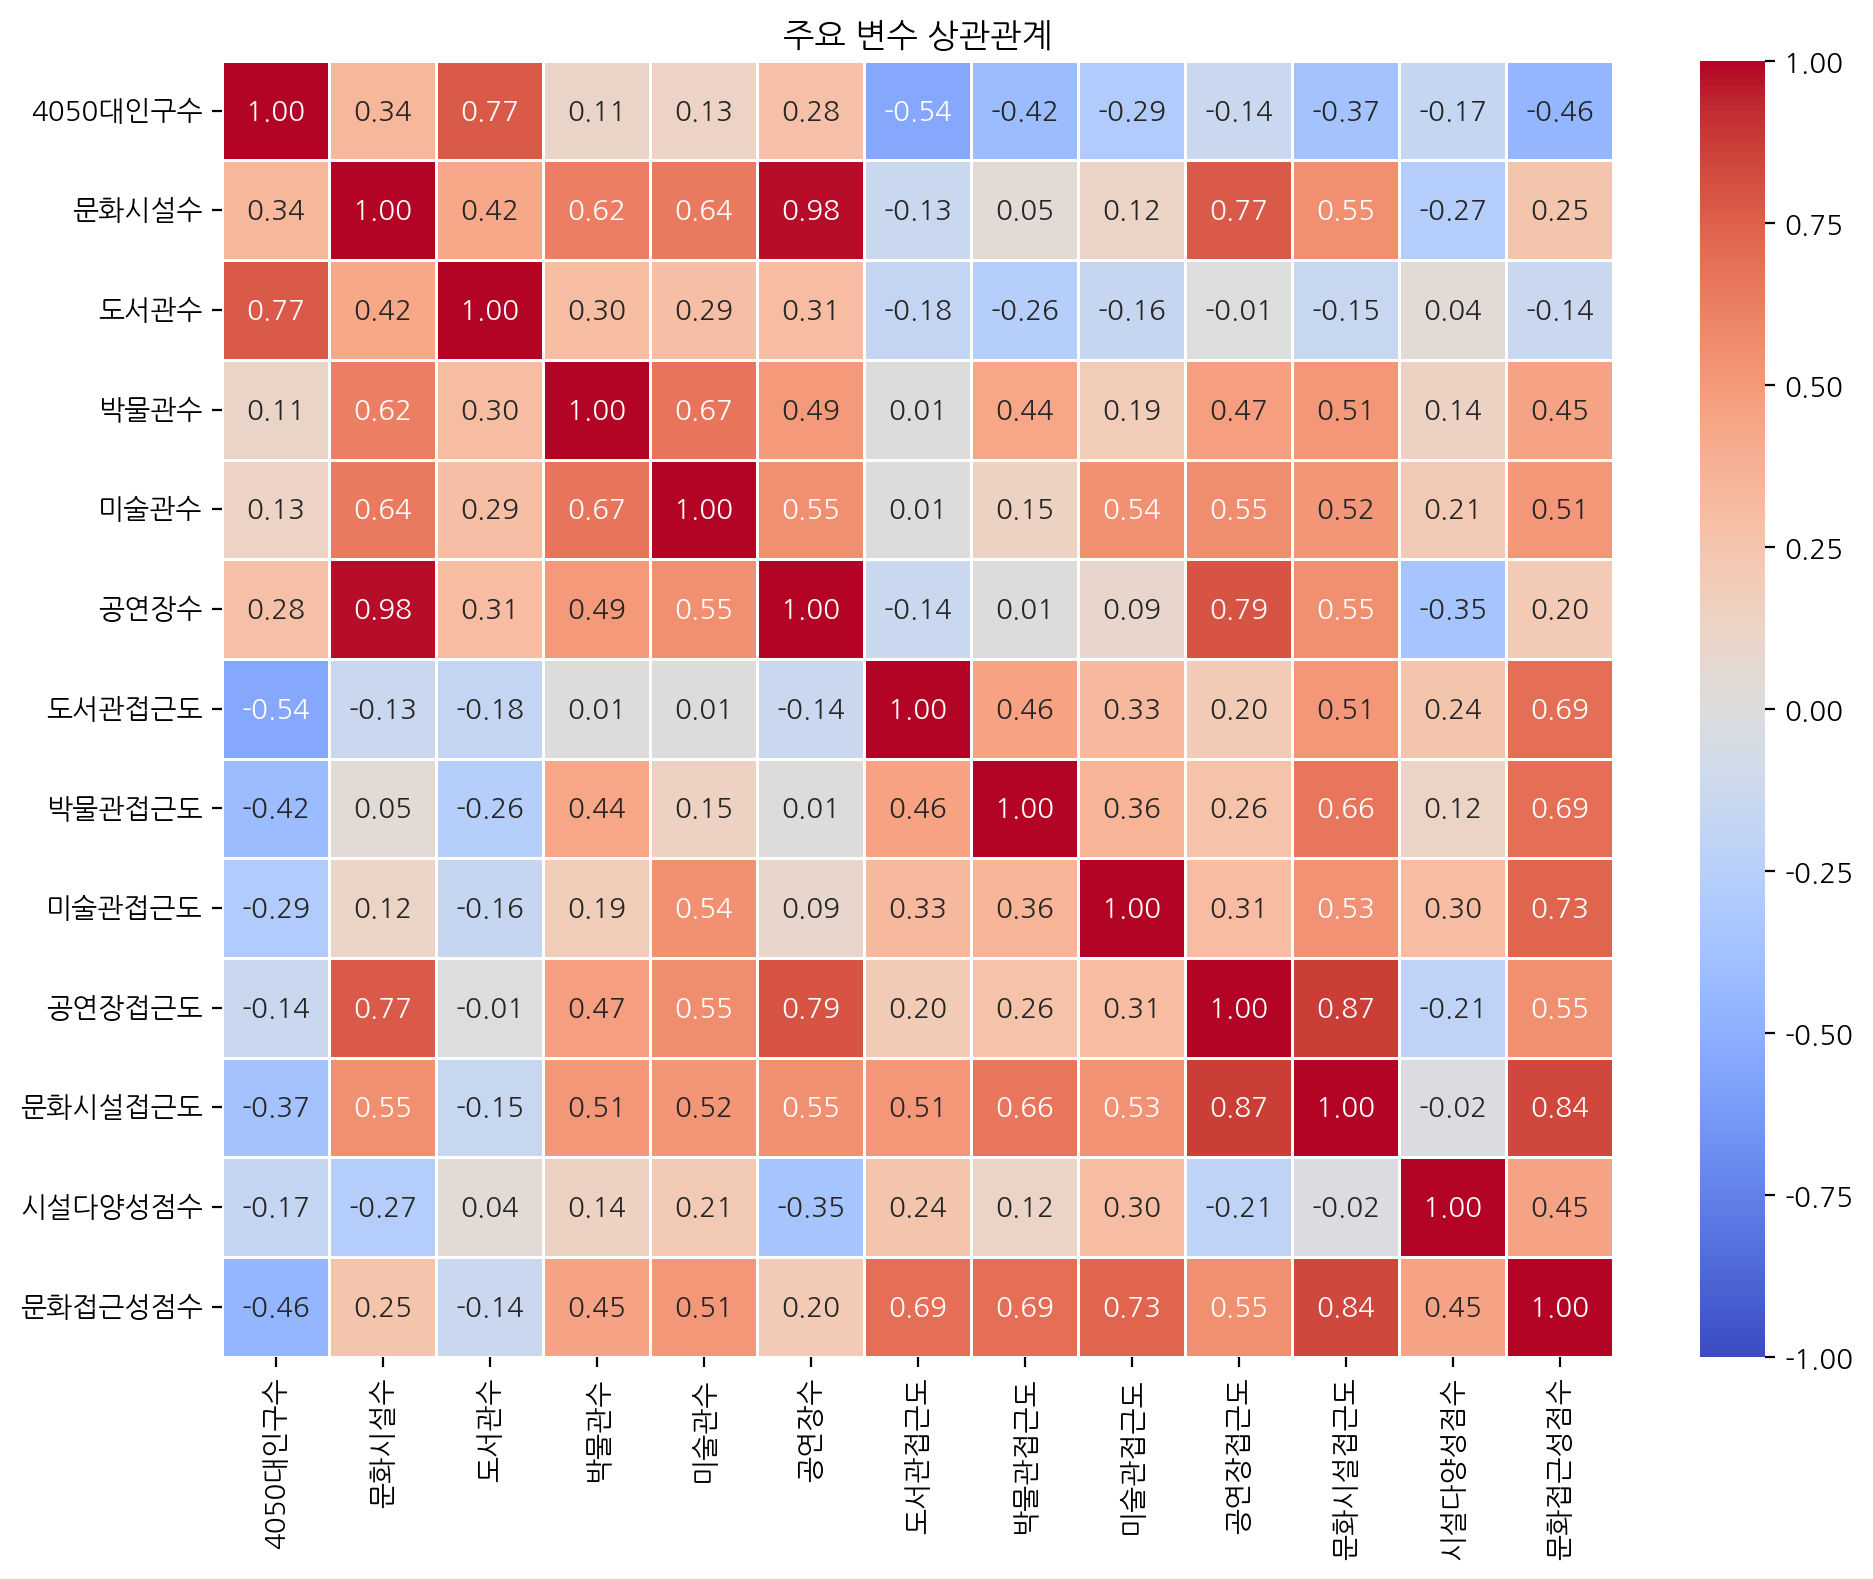

In [ ]:
# 시각화 17: 상관관계 히트맵
plt.figure(figsize=(10, 8))
if HAS_SEABORN:
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, linewidths=.4)
else:
    plt.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
    plt.colorbar()
    plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
    plt.yticks(range(len(corr.index)), corr.index)
plt.title("주요 변수 상관관계")
plt.tight_layout()
plt.show()

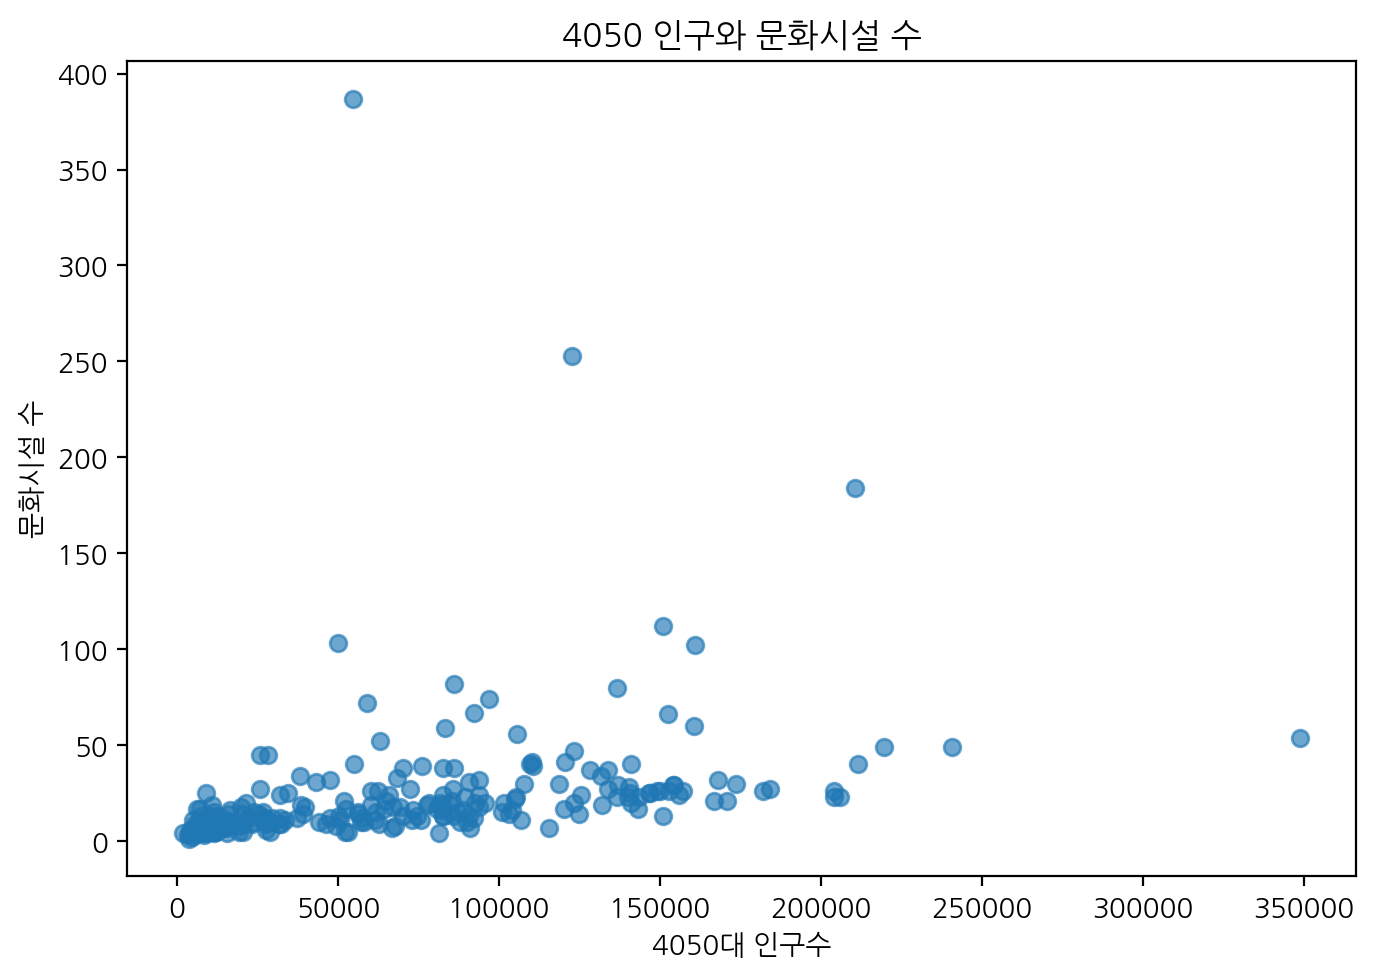

In [ ]:
# 시각화 18: 4050 인구와 문화시설 수
plt.figure(figsize=(7, 5))
plt.scatter(analysis["4050대인구수"], analysis["문화시설수"], alpha=0.65)
plt.xlabel("4050대 인구수")
plt.ylabel("문화시설 수")
plt.title("4050 인구와 문화시설 수")
plt.tight_layout()
plt.show()

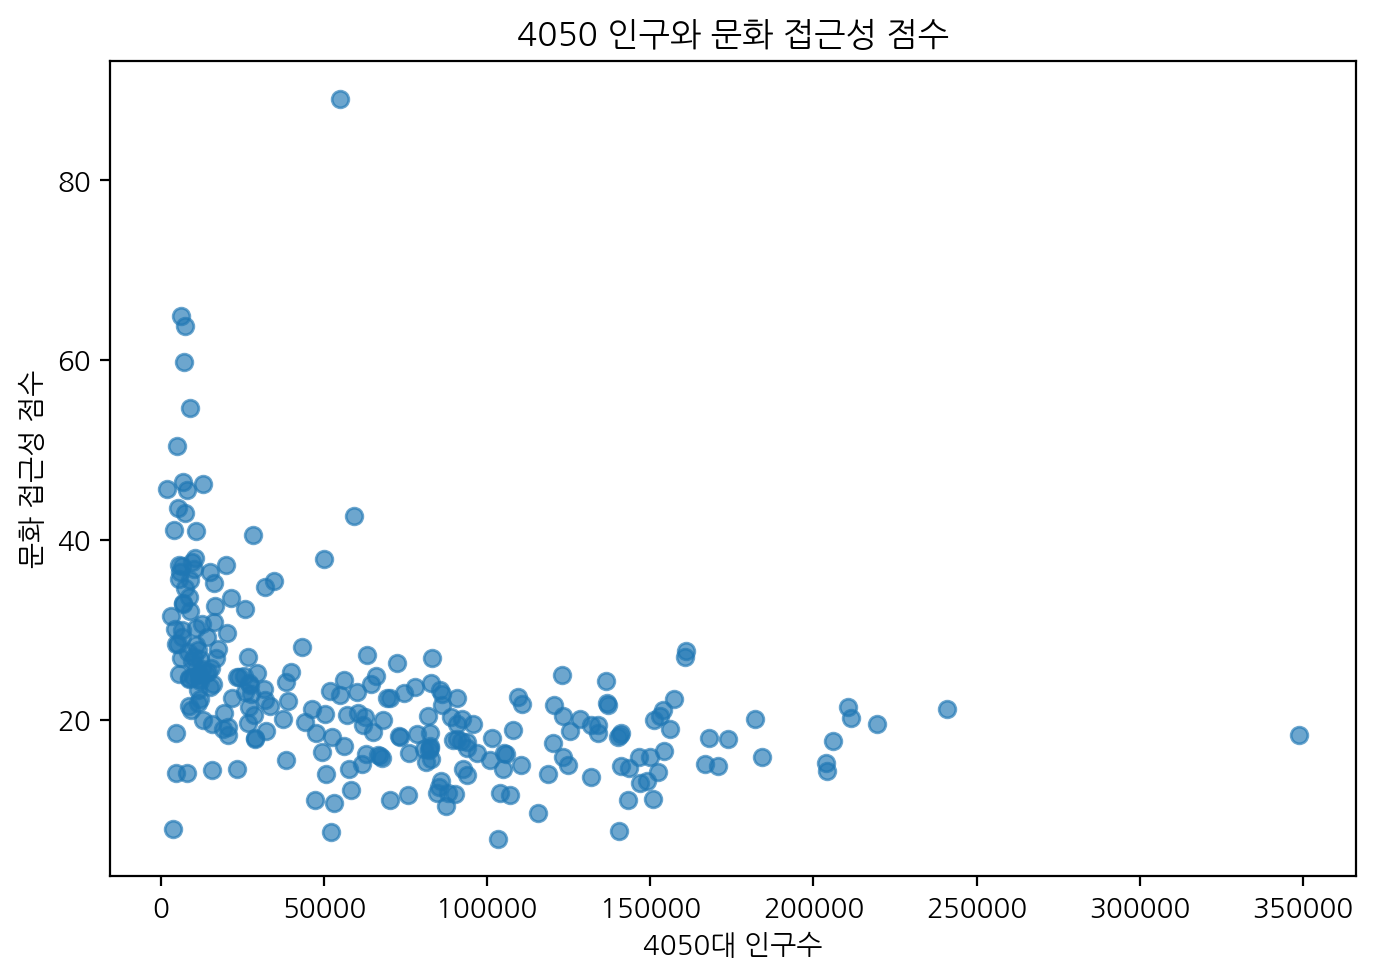

In [ ]:
# 시각화 19: 4050 인구와 문화 접근성 점수
plt.figure(figsize=(7, 5))
plt.scatter(analysis["4050대인구수"], analysis["문화접근성점수"], alpha=0.65)
plt.xlabel("4050대 인구수")
plt.ylabel("문화 접근성 점수")
plt.title("4050 인구와 문화 접근성 점수")
plt.tight_layout()
plt.show()

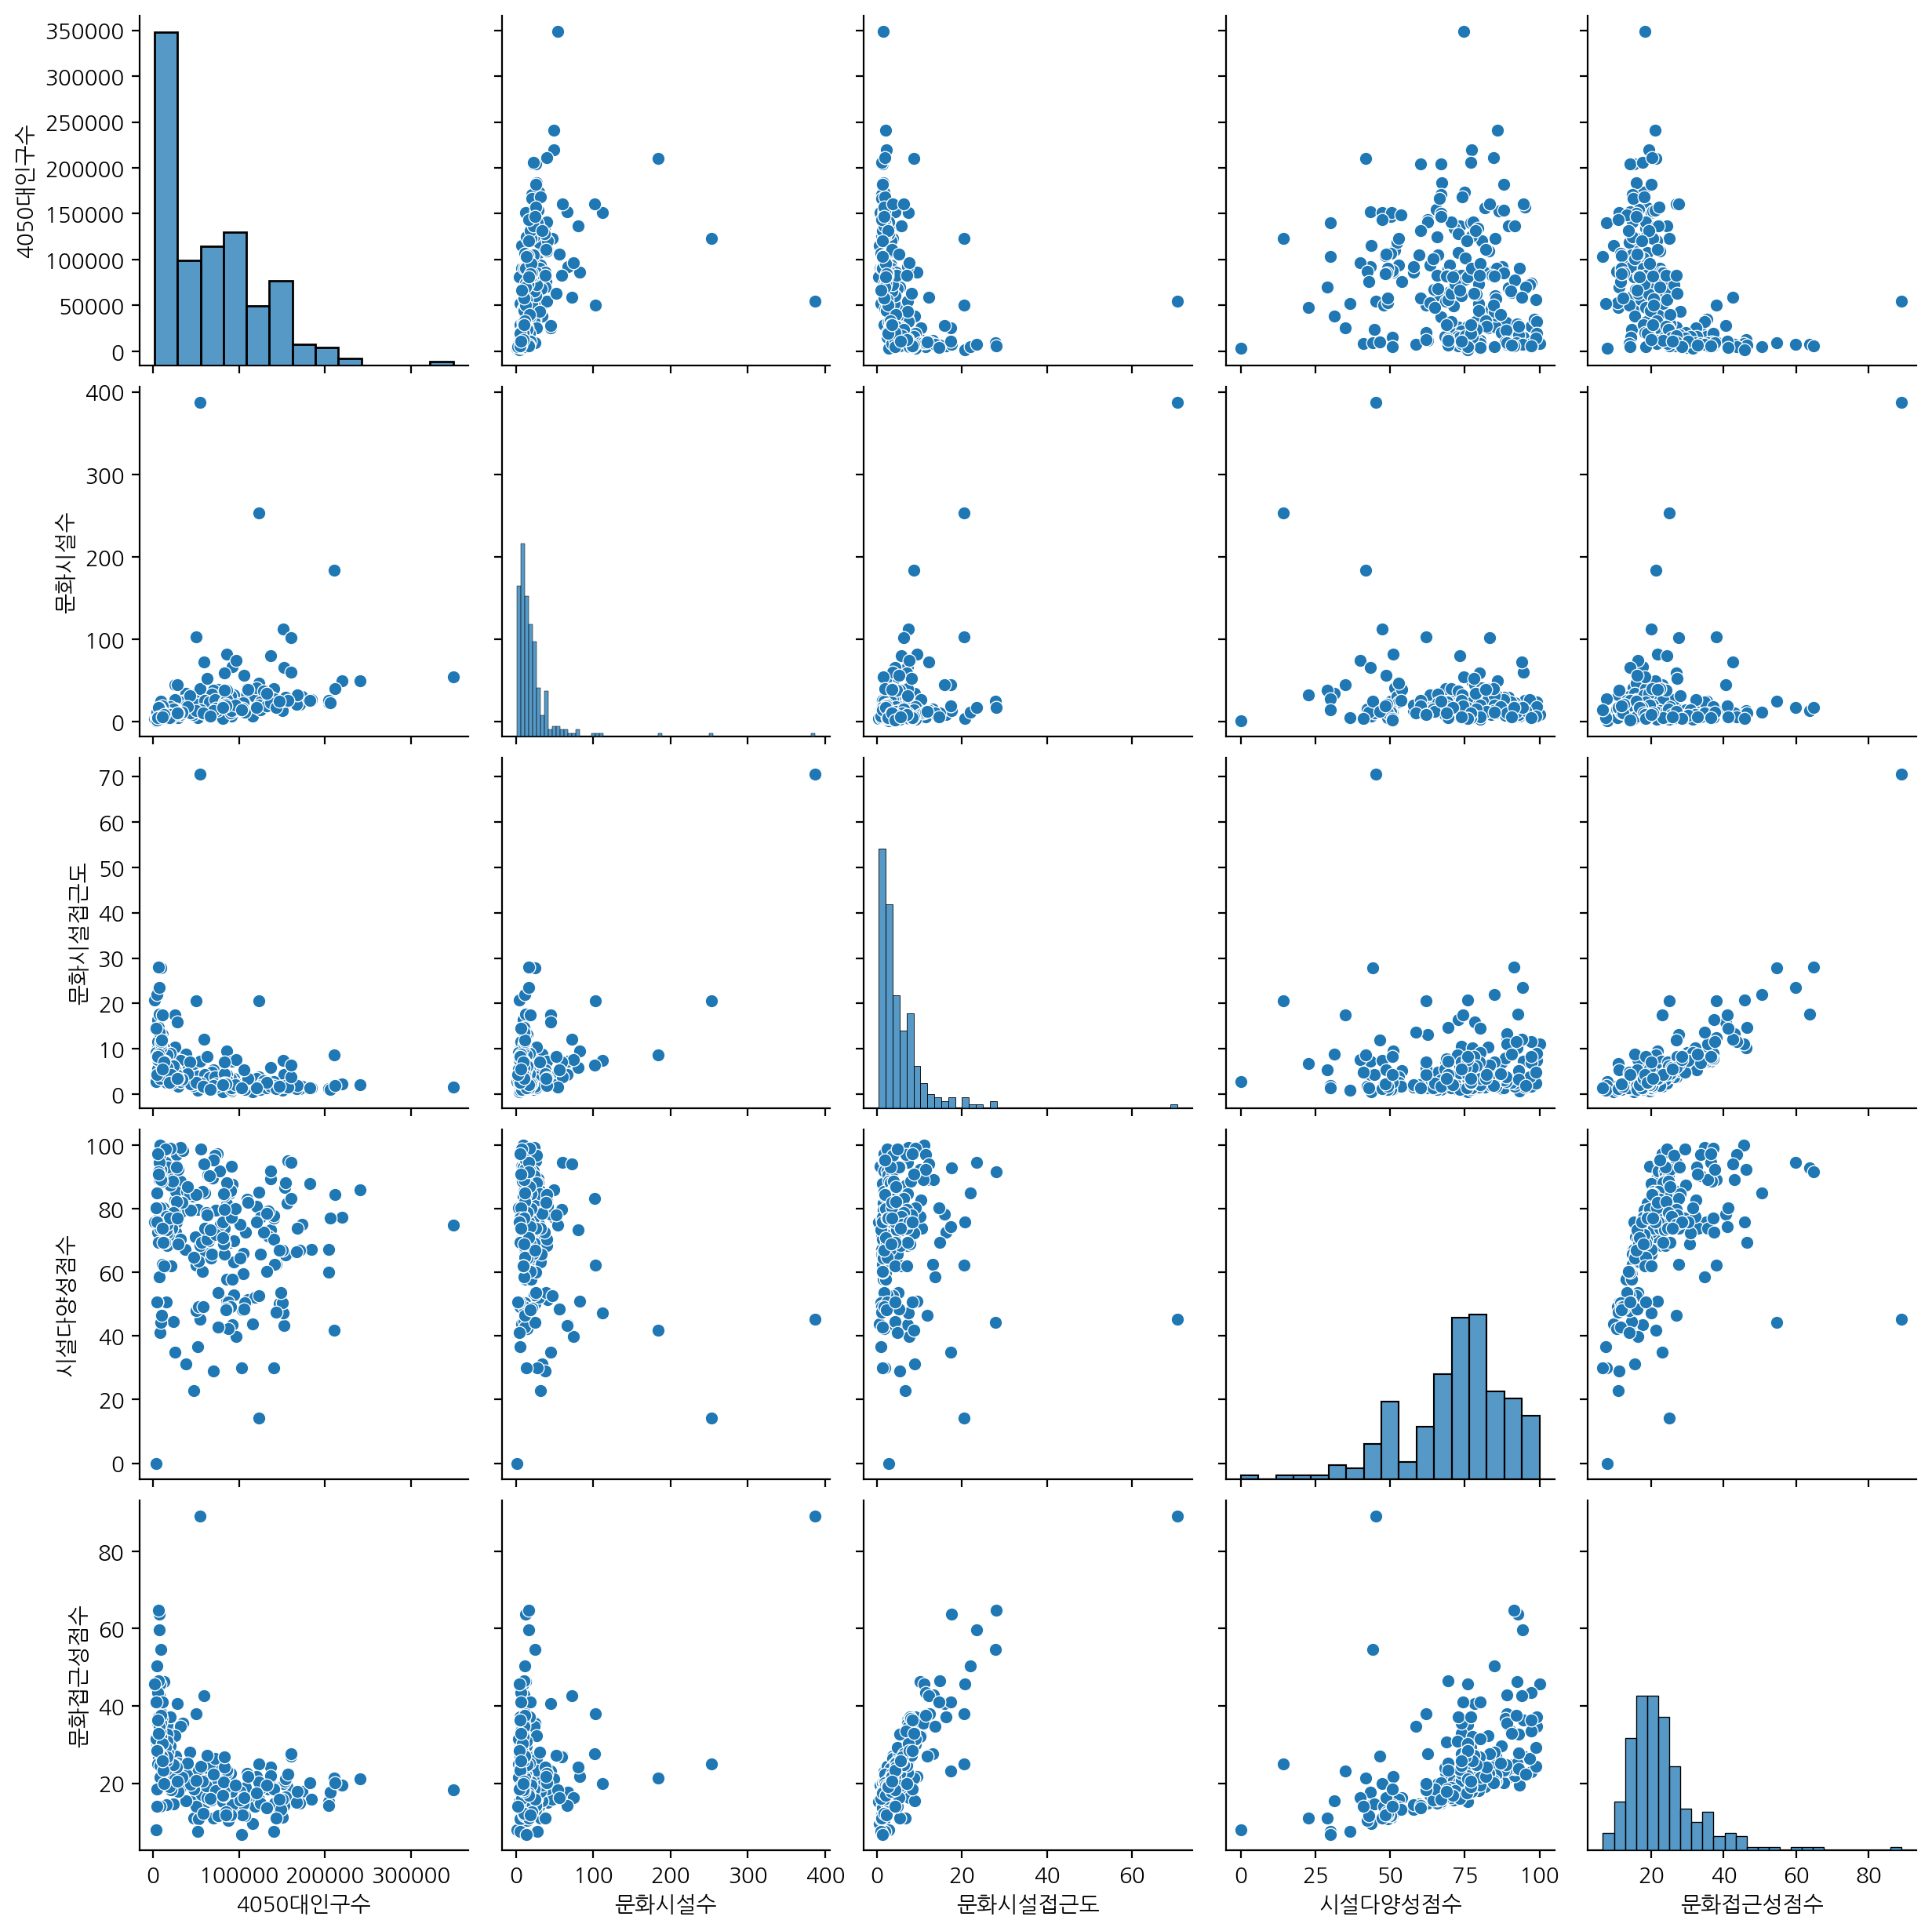

In [ ]:
# 시각화 20: pairplot
if HAS_SEABORN:
    sample_cols = ["4050대인구수", "문화시설수", "문화시설접근도", "시설다양성점수", "문화접근성점수"]
    sns.pairplot(analysis[sample_cols].dropna())
    plt.show()
else:
    print("seaborn이 없어 pairplot은 생략합니다.")

## 10. 문화 접근성 편중 지표

In [ ]:
def gini_coefficient(values):
    x = np.array(values, dtype=float)
    x = x[~np.isnan(x)]
    if len(x) == 0:
        return np.nan
    if np.min(x) < 0:
        x = x - np.min(x)
    x = x + 1e-9
    x = np.sort(x)
    n = len(x)
    return (2 * np.sum((np.arange(1, n + 1) * x)) / (n * np.sum(x))) - (n + 1) / n

gini_table = pd.DataFrame({
    "지표": ["문화시설접근도", "도서관접근도", "박물관접근도", "미술관접근도", "공연장접근도", "문화접근성점수"],
    "지니계수": [
        gini_coefficient(analysis["문화시설접근도"]),
        gini_coefficient(analysis["도서관접근도"]),
        gini_coefficient(analysis["박물관접근도"]),
        gini_coefficient(analysis["미술관접근도"]),
        gini_coefficient(analysis["공연장접근도"]),
        gini_coefficient(analysis["문화접근성점수"])
    ]
}).sort_values("지니계수", ascending=False)

gini_table

,지표,지니계수
3,미술관접근도,0.796
2,박물관접근도,0.647
4,공연장접근도,0.522
0,문화시설접근도,0.461
1,도서관접근도,0.434
5,문화접근성점수,0.219


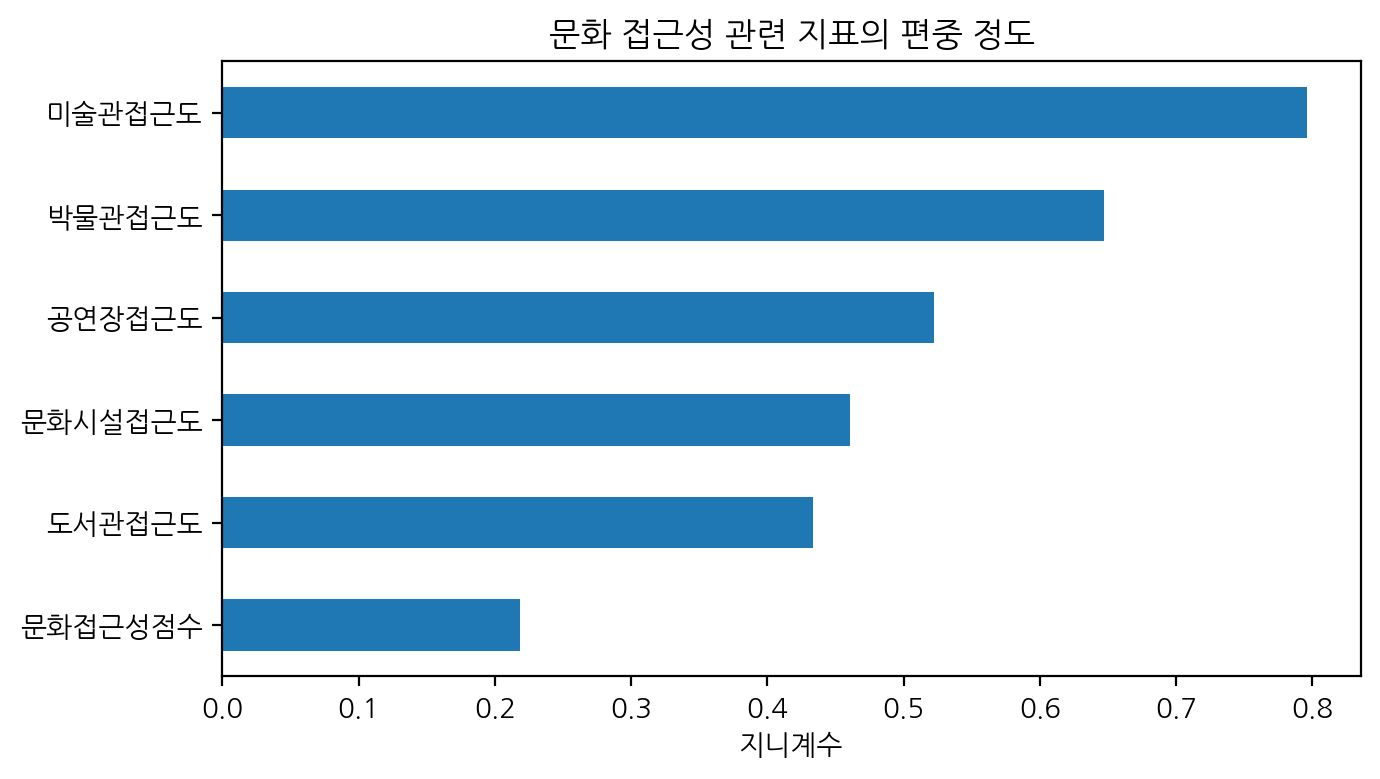

In [ ]:
# 시각화 21: 지니계수 비교
gini_table.sort_values("지니계수").plot(
    x="지표", y="지니계수", kind="barh", figsize=(7, 4),
    title="문화 접근성 관련 지표의 편중 정도", legend=False
)
plt.xlabel("지니계수")
plt.ylabel("")
plt.tight_layout()
plt.show()

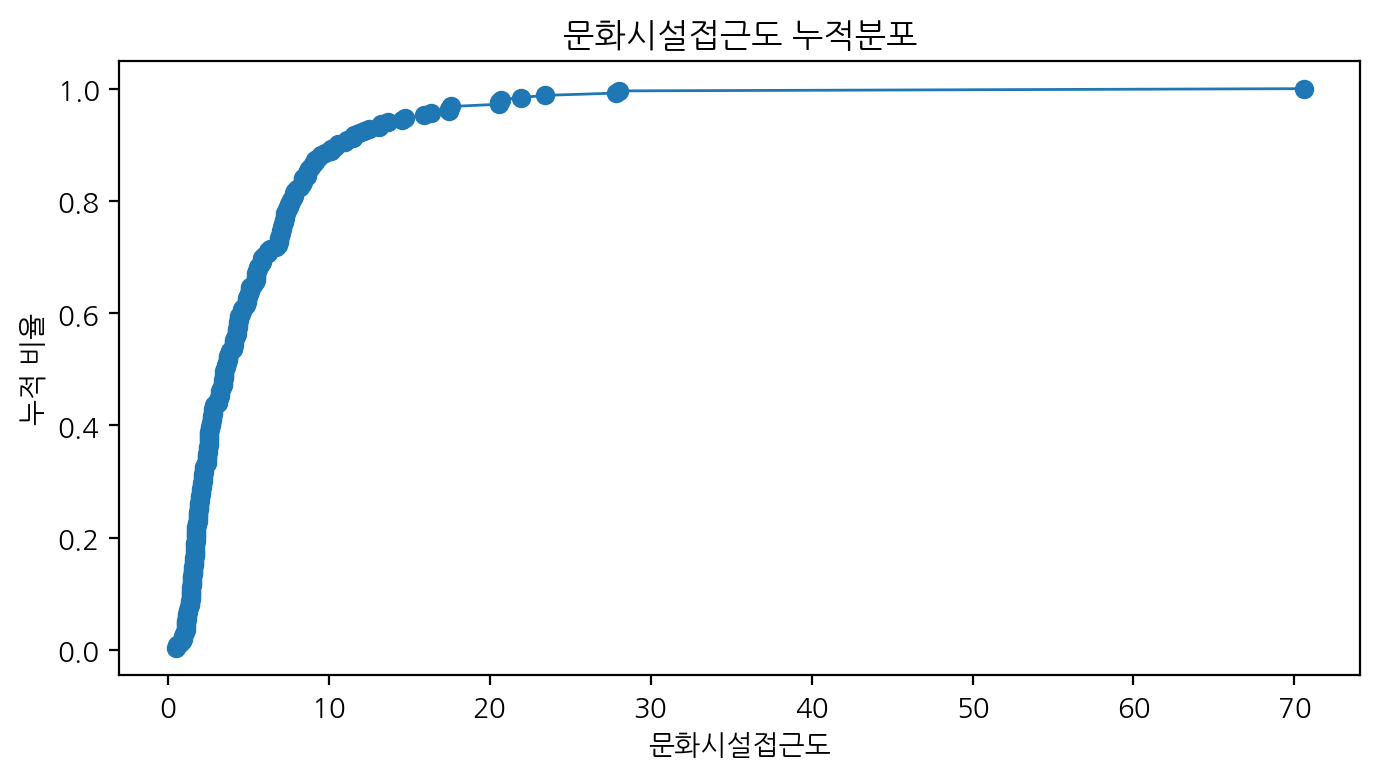

In [ ]:
# 시각화 22: 문화시설접근도 누적분포
x = np.sort(analysis["문화시설접근도"].dropna())
y = np.arange(1, len(x) + 1) / len(x)

plt.figure(figsize=(7, 4))
plt.plot(x, y, marker="o", linewidth=1)
plt.xlabel("문화시설접근도")
plt.ylabel("누적 비율")
plt.title("문화시설접근도 누적분포")
plt.tight_layout()
plt.show()

## 11. 지역 유형 분류

In [ ]:
cluster_features = [
    "4050대인구수", "문화시설접근도", "시설다양성점수", "문화접근성점수",
    "도서관접근도", "박물관접근도", "미술관접근도", "공연장접근도"
]

X = analysis[cluster_features].replace([np.inf, -np.inf], np.nan).fillna(0)
X_scaled = (X - X.mean()) / X.std().replace(0, 1)

np.random.seed(42)
k = 4
initial_idx = np.random.choice(len(X_scaled), size=k, replace=False)
centers = X_scaled.iloc[initial_idx].values

for step in range(50):
    dist = np.sqrt(((X_scaled.values[:, None, :] - centers[None, :, :]) ** 2).sum(axis=2))
    labels = dist.argmin(axis=1)
    new_centers = np.array([
        X_scaled.values[labels == i].mean(axis=0) if np.any(labels == i) else centers[i]
        for i in range(k)
    ])
    if np.allclose(centers, new_centers):
        break
    centers = new_centers

analysis["군집"] = labels
analysis["군집"].value_counts().sort_index()

,count
군집,
0,19
1,47
2,106
3,80


In [ ]:
cluster_summary = analysis.groupby("군집").agg(
    지역수=("시군구명", "count"),
    평균4050인구=("4050대인구수", "mean"),
    평균시설수=("문화시설수", "mean"),
    평균접근성=("문화접근성점수", "mean"),
    평균다양성=("시설다양성점수", "mean"),
    평균부족유형수=("부족유형수", "mean")
).sort_values("평균접근성")

cluster_summary

,지역수,평균4050인구,평균시설수,평균접근성,평균다양성,평균부족유형수
군집,,,,,,
1,47,"85,694.511",34.021,13.975,44.974,2.936
2,106,"103,817.189",22.962,19.250,77.287,2.585
3,80,"18,155.050",11.488,27.737,79.743,1.038
0,19,"15,638.842",41.368,48.831,78.832,0.474


In [ ]:
ordered_clusters = cluster_summary.index.tolist()
cluster_names = {}

if len(ordered_clusters) >= 4:
    cluster_names[ordered_clusters[0]] = "집중지원 필요형"
    cluster_names[ordered_clusters[1]] = "기초확충 필요형"
    cluster_names[ordered_clusters[2]] = "균형관리형"
    cluster_names[ordered_clusters[3]] = "연계확산형"
else:
    for i, c in enumerate(ordered_clusters):
        cluster_names[c] = f"군집{i}"

analysis["지역유형"] = analysis["군집"].map(cluster_names)
analysis["지역유형"].value_counts()

,count
지역유형,
기초확충 필요형,106
균형관리형,80
집중지원 필요형,47
연계확산형,19


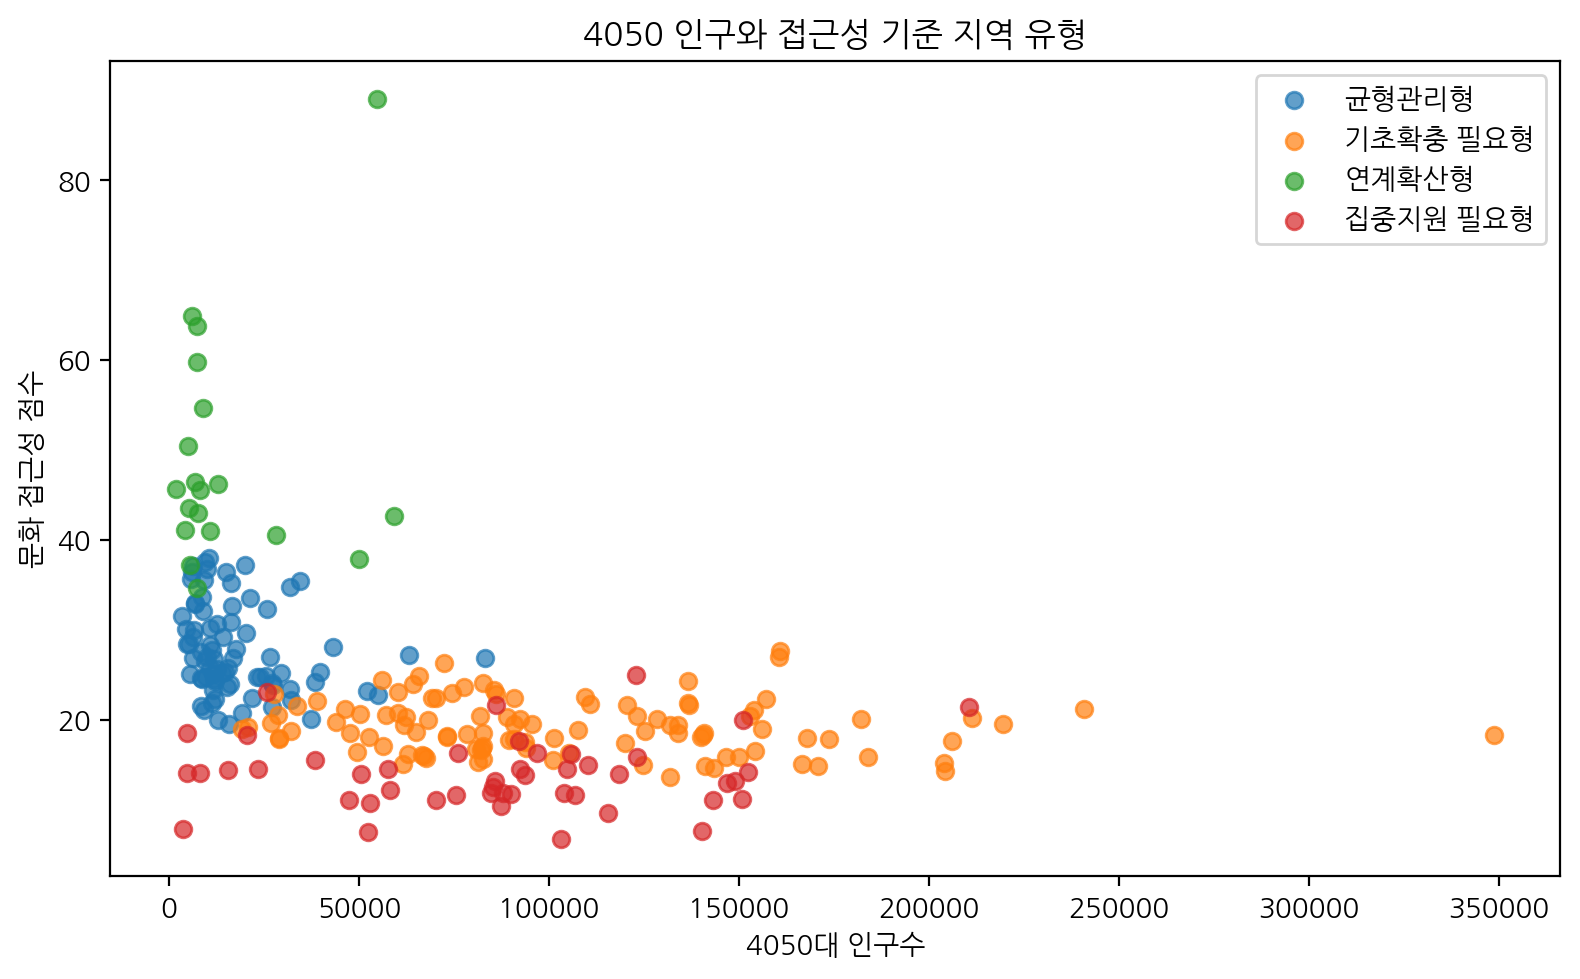

In [ ]:
# 시각화 23: 지역 유형 산점도
plt.figure(figsize=(8, 5))
for name, part in analysis.groupby("지역유형"):
    plt.scatter(part["4050대인구수"], part["문화접근성점수"], label=name, alpha=0.7)

plt.xlabel("4050대 인구수")
plt.ylabel("문화 접근성 점수")
plt.title("4050 인구와 접근성 기준 지역 유형")
plt.legend()
plt.tight_layout()
plt.show()

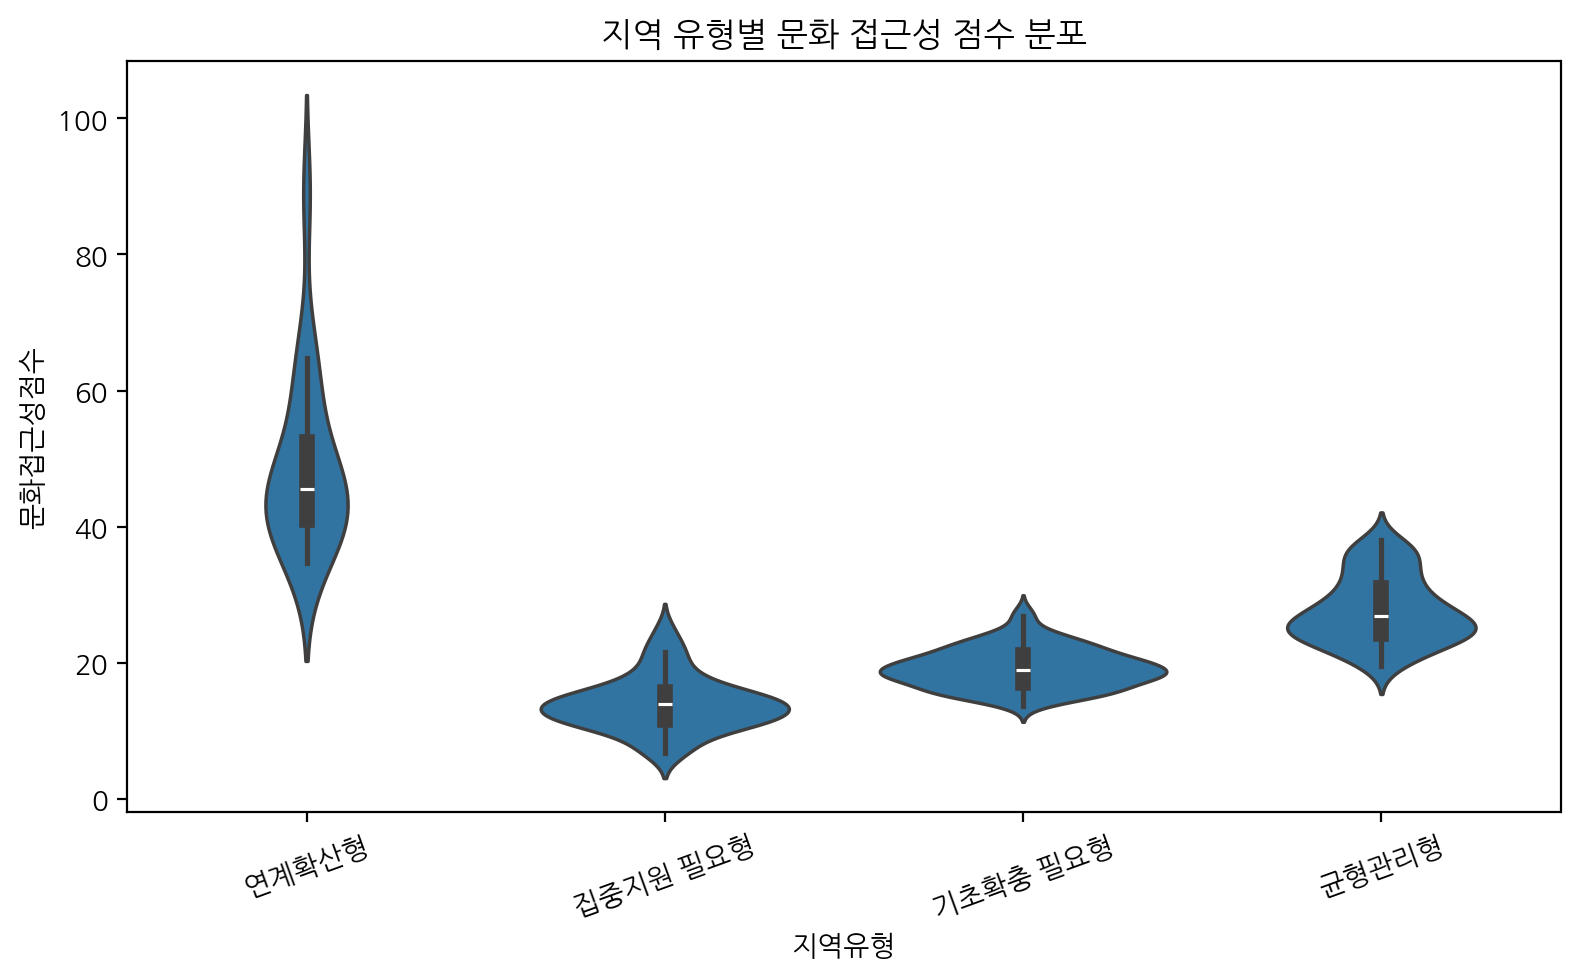

In [ ]:
# 시각화 24: 지역유형별 접근성 분포
if HAS_SEABORN:
    plt.figure(figsize=(8, 5))
    sns.violinplot(data=analysis, x="지역유형", y="문화접근성점수")
    plt.xticks(rotation=20)
    plt.title("지역 유형별 문화 접근성 점수 분포")
    plt.tight_layout()
    plt.show()
else:
    analysis.boxplot(column="문화접근성점수", by="지역유형", figsize=(8, 5))
    plt.title("지역 유형별 문화 접근성 점수 분포")
    plt.suptitle("")
    plt.xticks(rotation=20)
    plt.show()

## 12. 정책 우선순위 점수와 민감도 분석

In [ ]:
analysis["인구수요점수"] = minmax(analysis["4050대인구수"])
analysis["접근성부족점수"] = 1 - minmax(analysis["문화접근성점수"])
analysis["시설부족점수"] = analysis["부족유형수"] / 4
analysis["격차점수"] = minmax(analysis["수요공급격차"])

analysis["정책우선순위점수"] = (
    0.35 * analysis["인구수요점수"] +
    0.35 * analysis["접근성부족점수"] +
    0.20 * analysis["격차점수"] +
    0.10 * analysis["시설부족점수"]
) * 100

priority = analysis.sort_values("정책우선순위점수", ascending=False)

priority[[
    "시도명", "시군구명", "4050대인구수", "문화시설수", "문화접근성점수",
    "수요공급격차", "부족시설유형", "지역유형", "정책우선순위점수"
]].head(30)

,시도명,시군구명,4050대인구수,문화시설수,문화접근성점수,수요공급격차,부족시설유형,지역유형,정책우선순위점수
112,경기도,화성시,348863,54,18.332,167.000,"도서관,박물관,미술관,공연장",기초확충 필요형,92.849
90,경기도,평택시,204212,26,14.283,216.000,"도서관,박물관,미술관,공연장",기초확충 필요형,82.103
57,인천광역시,서구,203958,23,15.201,202.000,"도서관,박물관,미술관,공연장",기초확충 필요형,81.080
101,경기도,시흥시,206046,23,17.667,176.000,"도서관,박물관,미술관,공연장",기초확충 필요형,79.114
47,대구광역시,달서구,184118,27,15.816,194.000,"도서관,박물관,미술관,공연장",기초확충 필요형,78.470
64,광주광역시,광산구,150916,13,11.230,218.000,"도서관,박물관,미술관,공연장",집중지원 필요형,78.111
54,인천광역시,남동구,170896,21,14.889,203.000,"도서관,박물관,미술관,공연장",기초확충 필요형,77.920
135,충청남도,천안시 서북구,143138,17,11.024,215.000,"도서관,박물관,미술관,공연장",집중지원 필요형,77.284
55,인천광역시,부평구,166738,21,15.078,198.000,"도서관,박물관,미술관,공연장",기초확충 필요형,77.204
14,서울특별시,양천구,146830,25,12.930,206.000,"도서관,박물관,미술관,공연장",집중지원 필요형,76.456


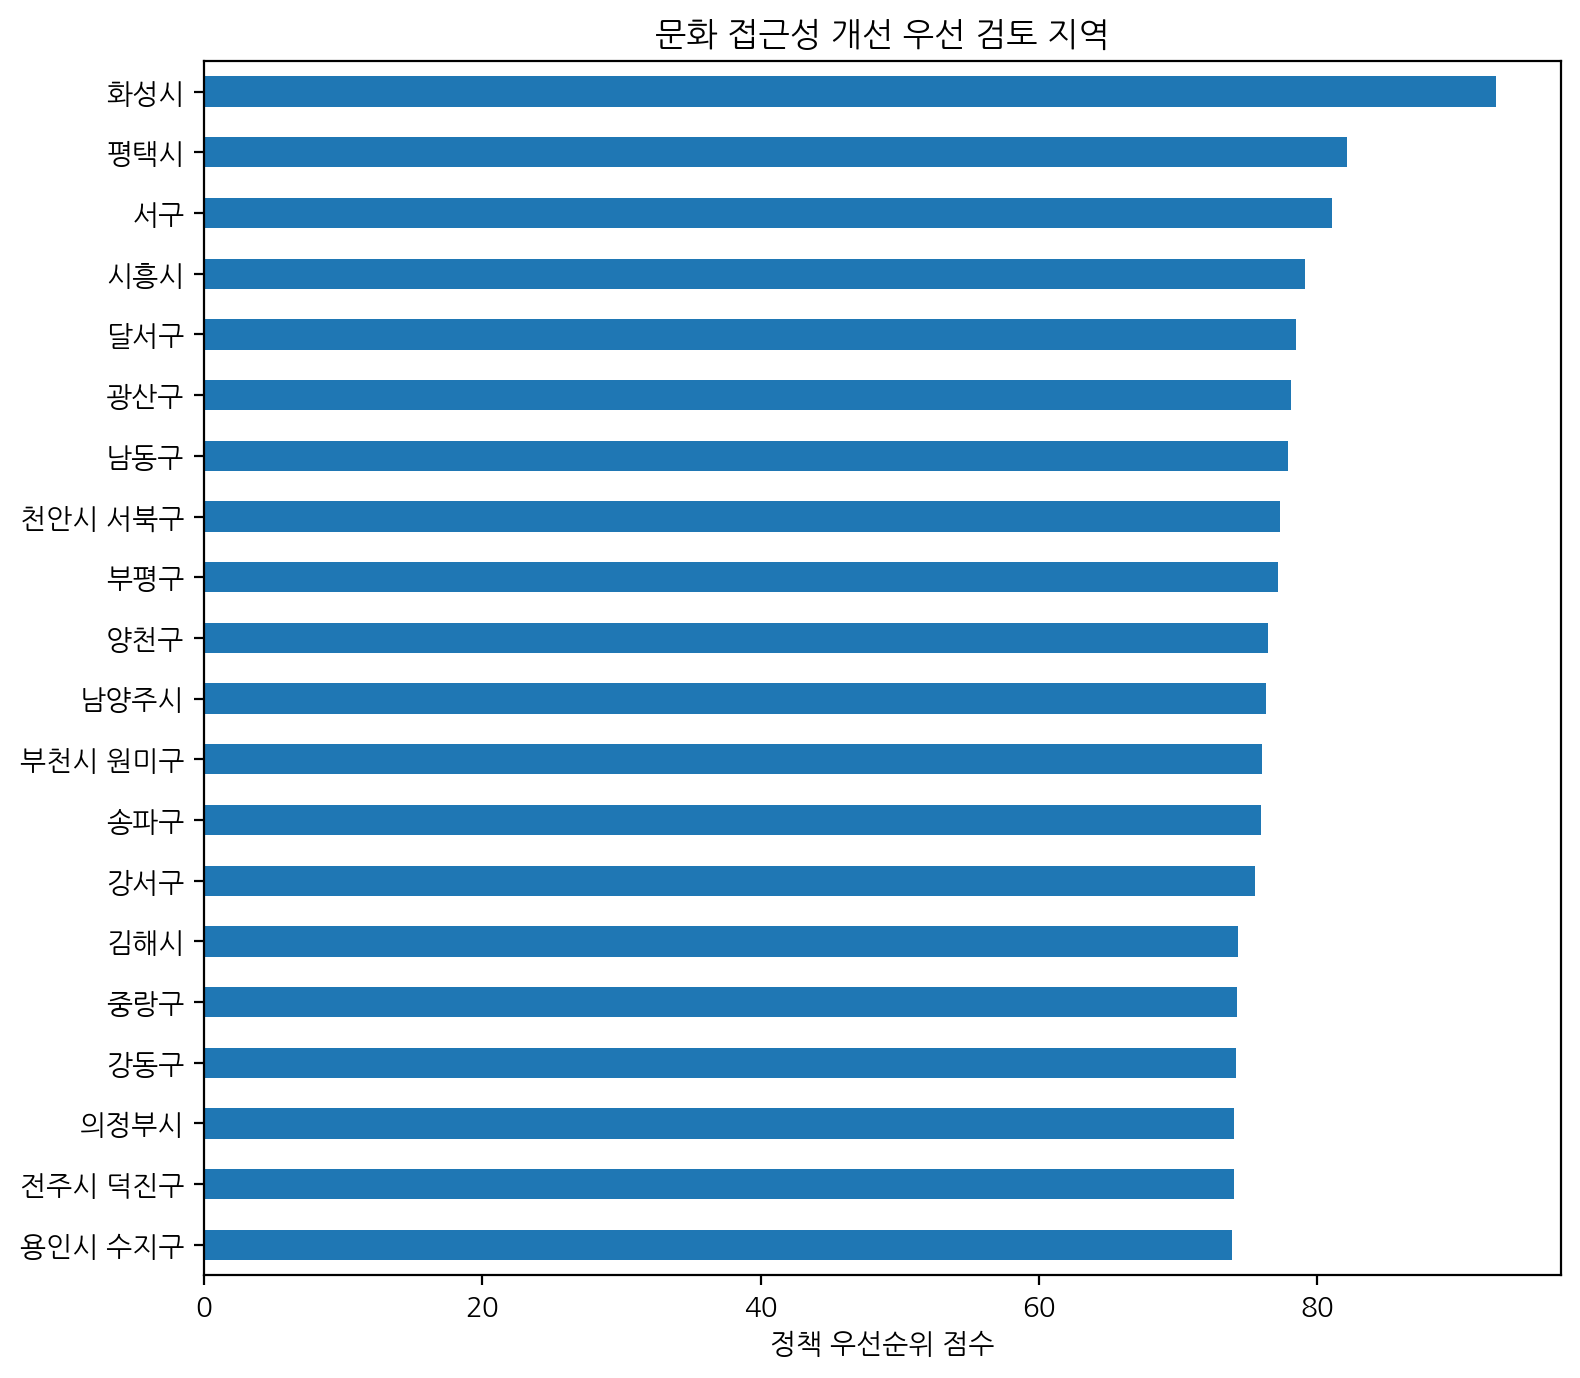

In [ ]:
# 시각화 25: 정책 우선순위 상위 20개 지역
priority.head(20).sort_values("정책우선순위점수").plot(
    x="시군구명", y="정책우선순위점수", kind="barh", figsize=(8, 7),
    title="문화 접근성 개선 우선 검토 지역", legend=False
)
plt.xlabel("정책 우선순위 점수")
plt.ylabel("")
plt.tight_layout()
plt.show()

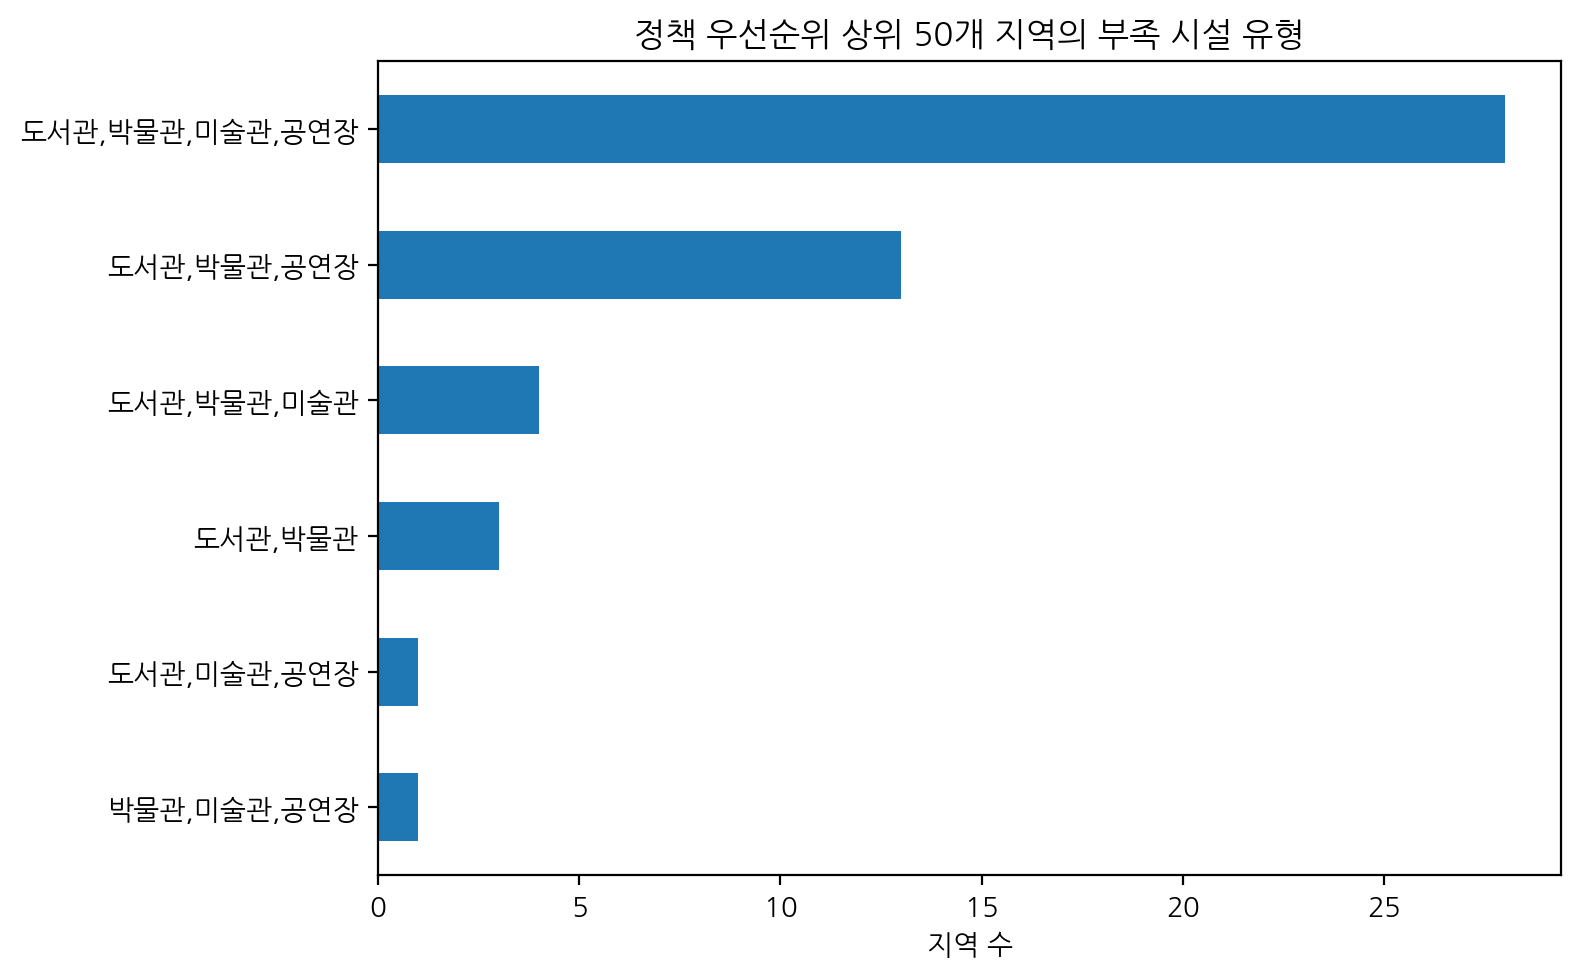

In [ ]:
# 시각화 26: 우선순위 지역의 부족 시설 유형 분포
priority.head(50)["부족시설유형"].value_counts().head(12).sort_values().plot(
    kind="barh", figsize=(8, 5), title="정책 우선순위 상위 50개 지역의 부족 시설 유형"
)
plt.xlabel("지역 수")
plt.ylabel("")
plt.tight_layout()
plt.show()

In [ ]:
# 가중치 민감도 분석
weight_scenarios = {
    "기본안": {"인구수요점수": 0.35, "접근성부족점수": 0.35, "격차점수": 0.20, "시설부족점수": 0.10},
    "접근성강화안": {"인구수요점수": 0.25, "접근성부족점수": 0.50, "격차점수": 0.15, "시설부족점수": 0.10},
    "수요강화안": {"인구수요점수": 0.50, "접근성부족점수": 0.25, "격차점수": 0.15, "시설부족점수": 0.10}
}

for scenario, w in weight_scenarios.items():
    analysis[scenario + "_점수"] = (
        w["인구수요점수"] * analysis["인구수요점수"] +
        w["접근성부족점수"] * analysis["접근성부족점수"] +
        w["격차점수"] * analysis["격차점수"] +
        w["시설부족점수"] * analysis["시설부족점수"]
    ) * 100
    analysis[scenario + "_순위"] = analysis[scenario + "_점수"].rank(ascending=False, method="min")

sensitivity_cols = ["시도명", "시군구명"] + [s + "_순위" for s in weight_scenarios.keys()]
analysis[sensitivity_cols].sort_values("기본안_순위").head(20)

,시도명,시군구명,기본안_순위,접근성강화안_순위,수요강화안_순위
112,경기도,화성시,1.000,1.000,1.000
90,경기도,평택시,2.000,2.000,2.000
57,인천광역시,서구,3.000,3.000,3.000
101,경기도,시흥시,4.000,9.000,4.000
47,대구광역시,달서구,5.000,7.000,6.000
64,광주광역시,광산구,6.000,4.000,11.000
54,인천광역시,남동구,7.000,8.000,8.000
135,충청남도,천안시 서북구,8.000,5.000,13.000
55,인천광역시,부평구,9.000,12.000,10.000
14,서울특별시,양천구,10.000,11.000,14.000


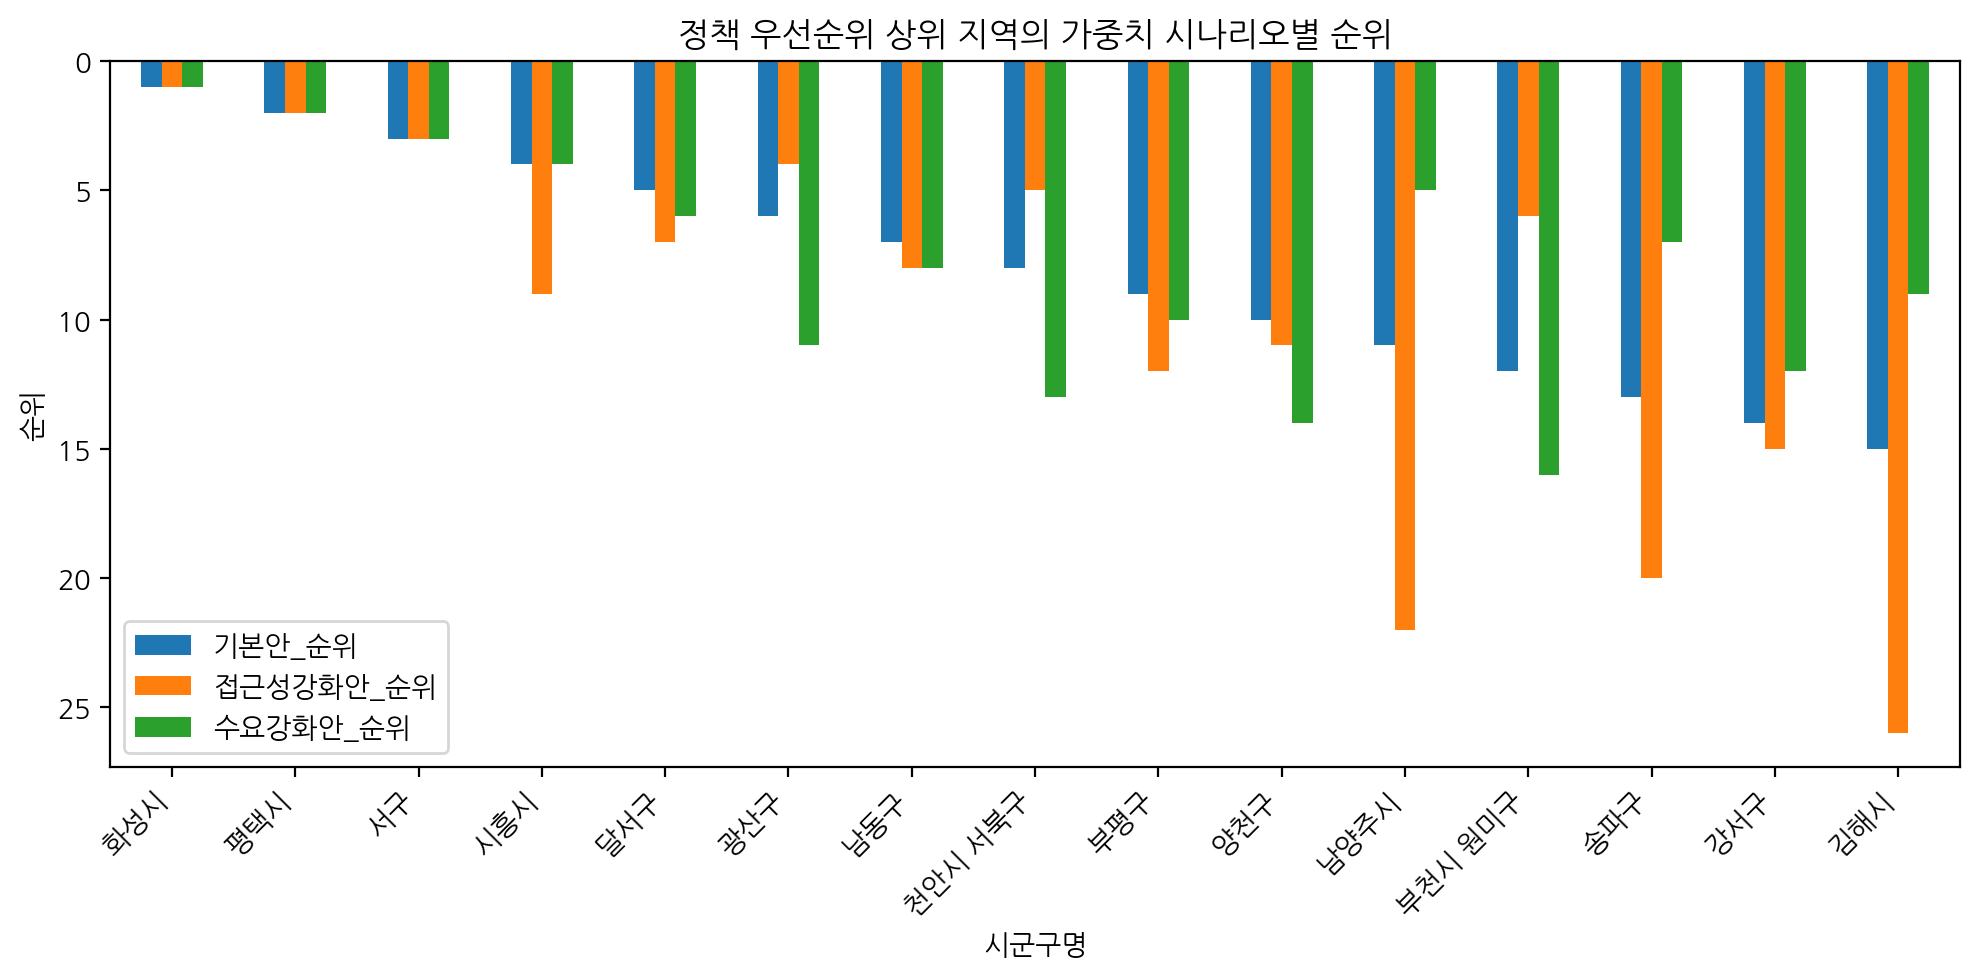

In [ ]:
# 시각화 27: 민감도 상위 지역 순위 비교
sens_top = analysis.sort_values("기본안_순위").head(15).copy()
sens_plot = sens_top.set_index("시군구명")[[s + "_순위" for s in weight_scenarios.keys()]]
sens_plot.plot(kind="bar", figsize=(10, 5), title="정책 우선순위 상위 지역의 가중치 시나리오별 순위")
plt.ylabel("순위")
plt.xticks(rotation=45, ha="right")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 13. 선택 사항: 디지털 문화역세권 데이터 결합

In [ ]:
digital_files = []
for p in ["*디지털*문화역세권*.csv", "*digital*culture*.csv", "*문화시설*검색*.csv", "*버즈*.csv"]:
    digital_files.extend(glob.glob(p))
digital_files = sorted(list(set(digital_files)))
digital_files

[]

In [ ]:
if len(digital_files) == 0:
    print("디지털 문화역세권 파일이 없어 확장 분석을 생략합니다.")
    digital = None
else:
    digital, enc = read_csv_safely(digital_files[0])
    print("디지털 데이터 파일:", digital_files[0])
    print("인코딩:", enc)
    display(digital.head())
    print(digital.columns.tolist())

디지털 문화역세권 파일이 없어 확장 분석을 생략합니다.


In [ ]:
if digital is not None:
    d = digital.copy()
    d.columns = [str(c).strip() for c in d.columns]

    sido_col = next((c for c in d.columns if c in ["시도명", "시도", "광역시도명"]), None)
    sig_col = next((c for c in d.columns if c in ["시군구명", "시군구", "기초지자체명"]), None)
    search_col = next((c for c in d.columns if "검색" in c or "search" in c.lower()), None)
    buzz_col = next((c for c in d.columns if "버즈" in c or "buzz" in c.lower()), None)

    print("시도 컬럼:", sido_col)
    print("시군구 컬럼:", sig_col)
    print("검색량 컬럼:", search_col)
    print("버즈량 컬럼:", buzz_col)

    if sido_col and sig_col and (search_col or buzz_col):
        use_cols = [sido_col, sig_col] + [c for c in [search_col, buzz_col] if c]
        d = d[use_cols].copy().rename(columns={sido_col: "시도명", sig_col: "시군구명"})
        for c in [search_col, buzz_col]:
            if c:
                d[c] = pd.to_numeric(d[c].astype(str).str.replace(",", "", regex=False), errors="coerce")
        agg_dict = {}
        if search_col:
            agg_dict[search_col] = "sum"
        if buzz_col:
            agg_dict[buzz_col] = "sum"
        digital_sig = d.groupby(["시도명", "시군구명"], as_index=False).agg(agg_dict)
        merged = analysis.merge(digital_sig, on=["시도명", "시군구명"], how="left")
        display(merged.head())
    else:
        print("자동 결합에 필요한 컬럼을 찾지 못했습니다. 컬럼명을 확인해 주세요.")

## 14. 지역별 추천 방향 생성

In [ ]:
def recommendation(row):
    lacks = [] if row["부족시설유형"] == "상대적 부족 없음" else row["부족시설유형"].split(",")

    if row["정책우선순위점수"] >= analysis["정책우선순위점수"].quantile(0.85):
        level = "우선 검토"
    elif row["정책우선순위점수"] >= analysis["정책우선순위점수"].quantile(0.60):
        level = "보완 검토"
    else:
        level = "현행 관리"

    if "공연장" in lacks:
        action = "순회공연·생활권 공연 프로그램 확대"
    elif "미술관" in lacks:
        action = "이동형 전시·지역 전시 연계 확대"
    elif "박물관" in lacks:
        action = "지역 문화유산 해설·체험 프로그램 연계"
    elif "도서관" in lacks:
        action = "도서관 기반 독서·문화 강좌 보강"
    else:
        action = "기존 시설 통합 안내와 프로그램 추천 고도화"

    return f"{level}: {action}"

analysis["맞춤추천방향"] = analysis.apply(recommendation, axis=1)

priority = analysis.sort_values("정책우선순위점수", ascending=False)
priority[["시도명", "시군구명", "정책우선순위점수", "부족시설유형", "맞춤추천방향"]].head(30)

,시도명,시군구명,정책우선순위점수,부족시설유형,맞춤추천방향
112,경기도,화성시,92.849,"도서관,박물관,미술관,공연장",우선 검토: 순회공연·생활권 공연 프로그램 확대
90,경기도,평택시,82.103,"도서관,박물관,미술관,공연장",우선 검토: 순회공연·생활권 공연 프로그램 확대
57,인천광역시,서구,81.080,"도서관,박물관,미술관,공연장",우선 검토: 순회공연·생활권 공연 프로그램 확대
101,경기도,시흥시,79.114,"도서관,박물관,미술관,공연장",우선 검토: 순회공연·생활권 공연 프로그램 확대
47,대구광역시,달서구,78.470,"도서관,박물관,미술관,공연장",우선 검토: 순회공연·생활권 공연 프로그램 확대
64,광주광역시,광산구,78.111,"도서관,박물관,미술관,공연장",우선 검토: 순회공연·생활권 공연 프로그램 확대
54,인천광역시,남동구,77.920,"도서관,박물관,미술관,공연장",우선 검토: 순회공연·생활권 공연 프로그램 확대
135,충청남도,천안시 서북구,77.284,"도서관,박물관,미술관,공연장",우선 검토: 순회공연·생활권 공연 프로그램 확대
55,인천광역시,부평구,77.204,"도서관,박물관,미술관,공연장",우선 검토: 순회공연·생활권 공연 프로그램 확대
14,서울특별시,양천구,76.456,"도서관,박물관,미술관,공연장",우선 검토: 순회공연·생활권 공연 프로그램 확대


In [ ]:
analysis["맞춤추천방향"].value_counts().head(15)

,count
맞춤추천방향,
현행 관리: 순회공연·생활권 공연 프로그램 확대,48
보완 검토: 순회공연·생활권 공연 프로그램 확대,44
현행 관리: 이동형 전시·지역 전시 연계 확대,41
우선 검토: 순회공연·생활권 공연 프로그램 확대,34
현행 관리: 기존 시설 통합 안내와 프로그램 추천 고도화,32
현행 관리: 지역 문화유산 해설·체험 프로그램 연계,15
현행 관리: 도서관 기반 독서·문화 강좌 보강,15
보완 검토: 지역 문화유산 해설·체험 프로그램 연계,9
보완 검토: 이동형 전시·지역 전시 연계 확대,8


## 15. 자동 인사이트 문장 생성

In [ ]:
top_sido = sido.sort_values("4050_1만명당시설수", ascending=False).iloc[0]
low_sido = sido.sort_values("4050_1만명당시설수", ascending=True).iloc[0]
top_region = top_access.iloc[0]
low_region = bottom_access.iloc[0]
priority_region = priority.iloc[0]
highest_gini = gini_table.iloc[0]

insights = pd.DataFrame({
    "구분": [
        "시도 격차",
        "상위 지역",
        "하위 지역",
        "정책 우선지역",
        "시설 편중",
        "분석 해석"
    ],
    "인사이트 문장": [
        f"4050 인구 1만 명당 문화시설 수는 {top_sido['시도명']}이 가장 높고, {low_sido['시도명']}이 가장 낮게 나타났다.",
        f"문화 접근성 점수 상위 지역은 {top_region['시도명']} {top_region['시군구명']}으로, 시설 접근도와 다양성 측면에서 상대적으로 우수했다.",
        f"문화 접근성 점수 하위 지역은 {low_region['시도명']} {low_region['시군구명']}으로, 부족 시설 유형은 {low_region['부족시설유형']}으로 나타났다.",
        f"정책 우선순위 점수가 가장 높은 지역은 {priority_region['시도명']} {priority_region['시군구명']}으로, 4050 인구수와 접근성 부족을 함께 고려할 때 우선 검토가 필요하다.",
        f"시설 접근성 관련 지표 중 편중 정도가 가장 큰 항목은 {highest_gini['지표']}이며, 지니계수는 {highest_gini['지니계수']:.3f}로 계산되었다.",
        "단순 시설 수보다 4050 인구 대비 접근도와 시설 유형별 부족 여부를 함께 봐야 문화 접근성 격차를 더 정확히 설명할 수 있다."
    ]
})

insights

,구분,인사이트 문장
0,시도 격차,"4050 인구 1만 명당 문화시설 수는 제주특별자치도이 가장 높고, 경기도이 가장 ..."
1,상위 지역,"문화 접근성 점수 상위 지역은 서울특별시 종로구으로, 시설 접근도와 다양성 측면에서..."
2,하위 지역,"문화 접근성 점수 하위 지역은 전북특별자치도 전주시 덕진구으로, 부족 시설 유형은 ..."
3,정책 우선지역,"정책 우선순위 점수가 가장 높은 지역은 경기도 화성시으로, 4050 인구수와 접근성..."
4,시설 편중,"시설 접근성 관련 지표 중 편중 정도가 가장 큰 항목은 미술관접근도이며, 지니계수는..."
5,분석 해석,단순 시설 수보다 4050 인구 대비 접근도와 시설 유형별 부족 여부를 함께 봐야 ...


## 16. 결과 저장

In [ ]:
analysis.to_csv("culture_access_analysis_final_result.csv", index=False, encoding="utf-8-sig")
sido.to_csv("culture_access_sido_summary.csv", index=False, encoding="utf-8-sig")
priority.head(50).to_csv("culture_access_policy_priority_top50.csv", index=False, encoding="utf-8-sig")
insights.to_csv("culture_access_key_insights.csv", index=False, encoding="utf-8-sig")

print("저장 완료")
print("culture_access_analysis_final_result.csv")
print("culture_access_sido_summary.csv")
print("culture_access_policy_priority_top50.csv")
print("culture_access_key_insights.csv")

저장 완료
culture_access_analysis_final_result.csv
culture_access_sido_summary.csv
culture_access_policy_priority_top50.csv
culture_access_key_insights.csv
